### Member
Thongkanok Pronchai 68070508012

Thanapat Podee 68070508044

In [1487]:
import pandas as pd
import numpy as np
import re
import difflib
import pycountry
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

pd.options.display.max_columns = 50
pd.options.display.max_rows = 100

In [1488]:
df_global = pd.read_csv(r'D:\Thx work\programming\Y4-2\data\homework 3\Comprehensive_Global_COVID-19_Dataset.csv', encoding='latin-1')
df_testing = pd.read_csv(r'D:\Thx work\programming\Y4-2\data\homework 3\Covid19-TestingRecord.csv')
df_variant = pd.read_csv(r'D:\Thx work\programming\Y4-2\data\homework 3\Covid19-VariantsFound.csv')
df_mfr = pd.read_csv(r'D:\Thx work\programming\Y4-2\data\homework 3\Vaccinations_ByCountry_ByManufacturer.csv')
df_vacc = pd.read_csv(r'D:\Thx work\programming\Y4-2\data\homework 3\Vaccinations_ByCountry.csv')

# Part 1: Data Integration

### File 1 — Comprehensive_Global

In [1489]:
# Drop แถว null ทั้งหมด 8 แถว
df_global = df_global.dropna(how='all').reset_index(drop=True)

# Drop คอลัมน์ S. No. ทีjเป็นแค่ running number จากไฟล์ต้นฉบับ ไม่ใช่ key ที่ใช้ระบุตัวตน 
df_global = df_global.drop(columns=['S. No.'])

# Rename "Country Name" → "country"
df_global = df_global.rename(columns={'Country Name': 'country'})

# ตัด "European Union" ออก
df_global = df_global[df_global['country'] != 'European Union'].copy()

df_global.tail(10)

,country,Cases,Deaths,Recovered
220,Democratic Republic of the Congo,100566.0,1470.0,99096.0
221,Sierra Leone,7818.0,125.0,7693.0
222,Nigeria,267188.0,3155.0,264033.0
223,South Sudan,18823.0,147.0,18676.0
224,Tanzania,43225.0,846.0,42379.0
225,Tajikistan,17786.0,125.0,17661.0
226,Benin,28036.0,163.0,27873.0
227,Niger,9515.0,315.0,9200.0
228,Chad,7702.0,194.0,7508.0
229,Burundi,54569.0,15.0,54554.0


### Missing value

In [1490]:
# ดู % ของแต่ละ column (ภาพรวม) บอกว่า column ไหนมีปัญหา
df_global.isnull().sum() / len(df_global) * 100

country      0.0
Cases        0.0
Deaths       0.0
Recovered    0.0
dtype: float64

### File 2 — TestingRecord

In [1491]:
# Split Entity → "country" + "metric_type" แยกคอลัมน์
# เช็คก่อนว่ามีคอลัมน์ 'Entity' อยู่หรือไม่ เพื่อป้องกัน Error เวลากดรัน Cell ซ้ำ
if 'Entity' in df_testing.columns:
    # Split Entity → "country" + "metric_type" แยกคอลัมน์
    df_testing[['country','metric_type']] = (
        df_testing['Entity'].str.split(' - ', n=1, expand=True)
    )
    df_testing['country'] = df_testing['country'].str.strip()
    
    # ลบคอลัมน์ Entity ทิ้ง
    df_testing = df_testing.drop(columns=['Entity'])
    
# จัดเรียงใหม่โดยเอา country และ metric_type ขึ้นก่อน ตามด้วยคอลัมน์อื่นๆ
other_cols = [col for col in df_testing.columns if col not in ['country', 'metric_type']]
df_testing = df_testing[['country', 'metric_type'] + other_cols]

# Rename "Date" → "date" และ parse เป็น datetime
df_testing = df_testing.rename(columns={'Date': 'date'})
df_testing['date'] = pd.to_datetime(df_testing['date'])


# สุ่มดูผลลัพธ์
# df_testing.sample(10)
df_testing[df_testing['country'] == 'Germany']

,country,metric_type,ISO code,date,Source URL,Source label,Notes,Daily change in cumulative total,Cumulative total,Cumulative total per thousand,Daily change in cumulative total per thousand,7-day smoothed daily change,7-day smoothed daily change per thousand,Short-term positive rate,Short-term tests per case
22894,Germany,tests performed,DEU,2020-03-15,https://www.rki.de/DE/Content/InfAZ/N/Neuartig...,Robert Koch Institut,NaN,NaN,129291.0,1.541,NaN,NaN,NaN,0.058,17.2
22895,Germany,tests performed,DEU,2020-03-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22896,Germany,tests performed,DEU,2020-03-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22897,Germany,tests performed,DEU,2020-03-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22898,Germany,tests performed,DEU,2020-03-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23520,Germany,tests performed,DEU,2021-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274720.0,3.274,NaN,NaN
23521,Germany,tests performed,DEU,2021-12-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,273808.0,3.263,NaN,NaN
23522,Germany,tests performed,DEU,2021-12-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,272896.0,3.253,NaN,NaN
23523,Germany,tests performed,DEU,2021-12-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,271984.0,3.242,NaN,NaN


### Missing value


In [1492]:
# ดู % ของแต่ละ column (ภาพรวม) บอกว่า column ไหนมีปัญหา
df_testing.isnull().sum() / len(df_testing) * 100

country                                           0.000000
metric_type                                       0.000000
ISO code                                          0.000000
date                                              0.000000
Source URL                                       14.953814
Source label                                     14.681018
Notes                                            88.735685
Daily change in cumulative total                 19.034950
Cumulative total                                 18.833729
Cumulative total per thousand                    18.833729
Daily change in cumulative total per thousand    19.034950
7-day smoothed daily change                       2.849503
7-day smoothed daily change per thousand          2.849503
Short-term positive rate                          8.394555
Short-term tests per case                         9.287219
dtype: float64

**1. Dropped Columns**
Notes, Source URL, Source label: Check if these columns exist in the table. If they do, drop them. The reason is that these columns contain only source references (metadata) or additional descriptions, not quantitative or primary variables used in data analysis. Deleting them reduces table redundancy.

**2. Forward Fill Columns**
Cumulative total (First step): Use forward fill, grouped by country and metric type. The reason is that this is a cumulative total. If no data is reported on a particular day, the latest cumulative value should be the same as the previous day. The date has been correctly sorted before executing this command to ensure the most accurate retrieval of values ​​from the top row.

**3. Columns calculated using derive and reverse engineering methods:**
- Daily change in cumulative total: This method uses derive from the daily difference (diff()) of the Cumulative total column (Plan A). The reason is that the daily change can be calculated from the difference in the cumulative total. If this column still contains empty values ​​(e.g., the first day's data with no previous day to delete), it will be filled with 0 (Plan B) to avoid NaN values.
- Cumulative total (Bug fix/Fallback step): The method used is to derive from the cumulative total (cumsum()) of the "Daily change in cumulative total" column. The reason is that if the data is missing from the very first row, Forward fill will not work. Therefore, the problem is solved by adding the daily values ​​back in cumulatively.
- Population (Temporary column): The method used is Reverse Engineering to calculate the population. Plan A calculates from (cumulative total / cumulative total per thousand) * 1000. If there are empty values, it switches to Plan B: (daily total / daily total per thousand) * 1000. Then, the first complete population value is retrieved and used to fill all rows for that country, to be used as the basis for the next calculation.
- Cumulative total per thousand: The method used is to derive from the formula (Cumulative total / population * 1000). The reason is that if the ratio per thousand is missing, the calculation will be incomplete. But we already have the cumulative total and population data. We can calculate the correct value directly.
- Daily change in cumulative total per thousand: Derive from the formula (Daily change / population * 1000). The reason is the same as above: it relies on dividing the daily change by the simulated population to accurately fill in any missing data gaps.

In [1493]:
# รายชื่อคอลัมน์เป้าหมายที่ต้องการลบ
target_cols = ['Notes', 'Source URL', 'Source label']

# กรองเอาเฉพาะคอลัมน์ที่ยังมีอยู่จริงในตาราง ถ้ามีคอลัมน์ให้ลบ ค่อยใช้คำสั่ง drop
cols_to_drop = [col for col in target_cols if col in df_testing.columns]
if cols_to_drop:
    df_testing = df_testing.drop(columns=cols_to_drop)

# ก่อนเริ่ม ต้องมั่นใจว่าข้อมูลเรียงลำดับเวลาถูกต้องแล้ว
df_testing = df_testing.sort_values(['country', 'metric_type', 'date'])

# มั่นใจว่าเรียงลำดับ Country -> Metric -> Date ถูกต้องก่อนทำ ffill
df_testing = df_testing.sort_values(['country', 'metric_type', 'date'])


#  0: (แก้ไขเพิ่มเติม) ถ้า Cumulative total เป็นช่องว่าง ให้ดึงค่าจากแถวบนลงมาเลย
df_testing['Cumulative total'] = (
    df_testing.groupby(['country', 'metric_type'])['Cumulative total']
    .transform(lambda x: x.ffill())
)

# 1: เช็ค daily change ถ้าไม่มีให้คำนวณจาก Cumulative total (ผลต่างรายวัน) ถ้าไม่มีข้อมูล Cumulative total ด้วย ให้ถือว่าการเปลี่ยนแปลงเป็น 0
calc_diff = (
    df_testing.groupby(['country', 'metric_type'])['Cumulative total']
    .transform(lambda x: x.diff())
)

df_testing['Daily change in cumulative total'] = (
    df_testing['Daily change in cumulative total']
    .fillna(calc_diff) # แผน A: เติมจากการคำนวณส่วนต่าง
    .fillna(0)         # แผน B: ถ้ายังแหว่งอยู่ (ไม่มีข้อมูลทั้งคู่อีก) ให้เป็น 0
)


# ข้อ 2: เช็ค Cumulative total อีกรอบ (กรณีที่ ffill ไม่ได้เพราะแหว่งตั้งแต่บรรทัดแรก) ให้เอา daily change มาทำยอดสะสม (cumsum) แทน

calc_cumsum = (
    df_testing.groupby(['country', 'metric_type'])['Daily change in cumulative total']
    .transform(lambda x: x.cumsum())
)
df_testing['Cumulative total'] = df_testing['Cumulative total'].fillna(calc_cumsum)



# ข้อ 3: คำนวณหาประชากร (Reverse Engineering) - อัปเดตลอจิก Fallback
# แผน A: คำนวณจากยอดสะสม (Cumulative)
pop_from_cumulative = (df_testing['Cumulative total'] / df_testing['Cumulative total per thousand']) * 1000

# แผน B: คำนวณจากยอดรายวัน (Daily) เผื่อแผน A เป็น NaN
pop_from_daily = (df_testing['Daily change in cumulative total'] / df_testing['Daily change in cumulative total per thousand']) * 1000

# สร้างคอลัมน์ประชากรชั่วคราว: เอาแผน A ตั้ง แล้วถ้าช่องไหนเป็น NaN ให้ดึงแผน B มาเติมแทน
df_testing['temp_pop'] = pop_from_cumulative.fillna(pop_from_daily)

# เนื่องจากใน 1 ประเทศควรมีประชากรเท่ากันทุกวัน 
# คำสั่ง .first() ของ groupby จะดึงค่าแรกสุดของประเทศนั้นที่ "ไม่เป็น NaN" มาใช้อัตโนมัติ
pop_mapping = df_testing.groupby('country')['temp_pop'].first()

# แมปค่าประชากรที่สมบูรณ์แล้วกลับเข้าไปในทุกๆ แถวของประเทศนั้นๆ
df_testing['population'] = df_testing['country'].map(pop_mapping)


# ข้อ 4: เช็ค Cumulative total per thousand ถ้าไม่มีเอา population ไปคำนวณ
calc_cum_per_k = (df_testing['Cumulative total'] / df_testing['population']) * 1000
df_testing['Cumulative total per thousand'] = df_testing['Cumulative total per thousand'].fillna(calc_cum_per_k)



# ข้อ 5: เช็ค Daily change per thousand ถ้าไม่มีคำนวณจาก population
calc_daily_per_k = (df_testing['Daily change in cumulative total'] / df_testing['population']) * 1000
df_testing['Daily change in cumulative total per thousand'] = df_testing['Daily change in cumulative total per thousand'].fillna(calc_daily_per_k)

# ลบคอลัมน์ประชากรชั่วคราวทิ้ง เพื่อความสะอาดของตาราง
df_testing = df_testing.drop(columns=['temp_pop', 'population'], errors='ignore')

# ลองเช็คผลลัพธ์ของประเทศที่ต้องการ
df_testing[df_testing['country'] == 'Germany']

,country,metric_type,ISO code,date,Daily change in cumulative total,Cumulative total,Cumulative total per thousand,Daily change in cumulative total per thousand,7-day smoothed daily change,7-day smoothed daily change per thousand,Short-term positive rate,Short-term tests per case
22894,Germany,tests performed,DEU,2020-03-15,0.0,129291.0,1.541000,0.000000,NaN,NaN,0.058,17.2
22895,Germany,tests performed,DEU,2020-03-16,0.0,129291.0,1.541000,0.000000,NaN,NaN,NaN,NaN
22896,Germany,tests performed,DEU,2020-03-17,0.0,129291.0,1.541000,0.000000,NaN,NaN,NaN,NaN
22897,Germany,tests performed,DEU,2020-03-18,0.0,129291.0,1.541000,0.000000,NaN,NaN,NaN,NaN
22898,Germany,tests performed,DEU,2020-03-19,0.0,129291.0,1.541000,0.000000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
23520,Germany,tests performed,DEU,2021-12-01,0.0,85885400.0,1023.655176,0.000000,274720.0,3.274,NaN,NaN
23521,Germany,tests performed,DEU,2021-12-02,0.0,85885400.0,1023.655176,0.000000,273808.0,3.263,NaN,NaN
23522,Germany,tests performed,DEU,2021-12-03,0.0,85885400.0,1023.655176,0.000000,272896.0,3.253,NaN,NaN
23523,Germany,tests performed,DEU,2021-12-04,0.0,85885400.0,1023.655176,0.000000,271984.0,3.242,NaN,NaN


### File 3 — VariantsFound

In [1494]:
# Rename "location" → "country" + parse date
df_variant = df_variant.rename(columns={'location': 'country'})
df_variant['date'] = pd.to_datetime(df_variant['date'])

df_variant

,country,date,variant,num_sequences,perc_sequences,num_sequences_total
0,Angola,2020-07-06,Alpha,0,0.0,3
1,Angola,2020-07-06,B.1.1.277,0,0.0,3
2,Angola,2020-07-06,B.1.1.302,0,0.0,3
3,Angola,2020-07-06,B.1.1.519,0,0.0,3
4,Angola,2020-07-06,B.1.160,0,0.0,3
...,...,...,...,...,...,...
100411,Zimbabwe,2021-11-01,Omicron,0,0.0,6
100412,Zimbabwe,2021-11-01,S:677H.Robin1,0,0.0,6
100413,Zimbabwe,2021-11-01,S:677P.Pelican,0,0.0,6
100414,Zimbabwe,2021-11-01,others,0,0.0,6


### Missing value

In [1495]:
# ดู % ของแต่ละ column (ภาพรวม) บอกว่า column ไหนมีปัญหา
df_variant.isnull().sum() / len(df_variant) * 100

country                0.0
date                   0.0
variant                0.0
num_sequences          0.0
perc_sequences         0.0
num_sequences_total    0.0
dtype: float64

### File 4 — Vaccinations_ByCountry

Remove sub-nationals, keep United Kingdom.
Because (1) the numbers are 100% duplicated, (2) other files use "United Kingdom", and (3) the goal is to analyze at the national level.
If you want to analyze sub-nationals, use a separate dataset, not include them together.

In [1496]:
# ระบุ iso_code ของแคว้นใน UK ที่ต้องการตัดออก
uk_subnations = ['OWID_ENG', 'OWID_SCT', 'OWID_WLS', 'OWID_NIR']

# ใช้ ~ และ .isin() เพื่อเก็บเฉพาะข้อมูลที่ "ไม่อยู่" ในลิสต์ด้านบน
df_vacc = df_vacc[~df_vacc['iso_code'].isin(uk_subnations)].copy()

# รายชื่อคอลัมน์เป้าหมายที่ต้องการลบ
target_cols = ['source_name', 'source_website']

# กรองเอาเฉพาะคอลัมน์ที่ยังมีอยู่จริงในตาราง ถ้ามีคอลัมน์ให้ลบ ค่อยใช้คำสั่ง drop
cols_to_drop = [col for col in target_cols if col in df_vacc.columns]
if cols_to_drop:
    df_vacc = df_vacc.drop(columns=cols_to_drop)

# Parse date เป็น datetime
df_vacc['date'] = pd.to_datetime(df_vacc['date'])

df_vacc.head(10)

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.00,0.00,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
5,Afghanistan,AFG,2021-02-27,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
6,Afghanistan,AFG,2021-02-28,8200.0,8200.0,NaN,NaN,1367.0,0.02,0.02,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
7,Afghanistan,AFG,2021-03-01,NaN,NaN,NaN,NaN,1580.0,NaN,NaN,NaN,40.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
8,Afghanistan,AFG,2021-03-02,NaN,NaN,NaN,NaN,1794.0,NaN,NaN,NaN,45.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
9,Afghanistan,AFG,2021-03-03,NaN,NaN,NaN,NaN,2008.0,NaN,NaN,NaN,50.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."


### Missing value

In [1497]:
# ดู % ของแต่ละ column (ภาพรวม) บอกว่า column ไหนมีปัญหา
df_vacc.isnull().sum() / len(df_vacc) * 100

country                                 0.000000
iso_code                                0.000000
date                                    0.000000
total_vaccinations                     50.595941
people_vaccinated                      53.325466
people_fully_vaccinated                56.266226
daily_vaccinations_raw                 60.310361
daily_vaccinations                      0.348124
total_vaccinations_per_hundred         50.595941
people_vaccinated_per_hundred          53.325466
people_fully_vaccinated_per_hundred    56.266226
daily_vaccinations_per_million          0.348124
vaccines                                0.000000
dtype: float64

**1. Columns using Interpolation and Zero Filling:**
* **Total Vaccinations, People Vaccinated, etc. Columns:**
* **Linear Interpolation:** Use forward linear interpolation for country groups. The reason is that these values ​​are cumulative and only increase. Interpolation helps create missing data points that gradually increase proportionally (the graph will be smooth as a sloping line), which better reflects the reality of vaccination than normal forward fill which would flatten the numbers and create a stair-like jump.
* **Fill 0:** After interpolation, if there are still NaN values ​​remaining (which logically represent the "first few days" in the table where that country has no vaccinations yet), fill in the remaining NaN values. Therefore, there is no initial value for interpolation. The code uses a last-ditch method to fill in the gap by adding a 0, which makes sense because it means no one has been vaccinated yet.

**2. Columns using forward fill**
* **daily_vaccinations:** Uses forward fill based on country groups. The reason is that this column usually contains smoothed or averaged data. If the report is missing some days, using the previous day's forecast to fill it in is a safe method that doesn't significantly distort the data trend.

**3. Columns calculated from other columns (Derive)**
* **daily_vaccinations_raw:** Uses derive from the daily difference (diff()) of the total_vaccinations column (cumulative total). The reason is that once we have perfected the cumulative total column (no gaps and correctly sorted chronologically), we don't need to guess this value. We can directly calculate the "true daily vaccination total (Raw)" by subtracting yesterday's cumulative total from today's total.

In [1498]:
df_vacc = df_vacc.sort_values(['country','date'])

cumul_cols = ['total_vaccinations','people_vaccinated','people_fully_vaccinated',
              'total_vaccinations_per_hundred','people_vaccinated_per_hundred',
              'people_fully_vaccinated_per_hundred']

for col in cumul_cols:
    df_vacc[col] = (
        df_vacc.groupby('country')[col]
        .transform(lambda x: x.interpolate(method='linear', limit_direction='forward'))
    )
df_vacc[cumul_cols] = df_vacc[cumul_cols].fillna(0)

# Derive daily raw จาก cumulative
df_vacc['daily_vaccinations_raw'] = (
    df_vacc.groupby('country')['total_vaccinations']
    .transform(lambda x: x.diff())
)

# ffill daily (smoothed)
df_vacc['daily_vaccinations'] = (
    df_vacc.groupby('country')['daily_vaccinations']
    .transform(lambda x: x.ffill())
)
df_vacc
# df_vacc.loc[0:20,['total_vaccinations','daily_vaccinations_raw','daily_vaccinations','daily_vaccinations_per_million']]
# df_vacc.loc[df_vacc['country']=='Austria']

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines
0,Afghanistan,AFG,2021-02-22,0.000000e+00,0.000000e+00,0.0,NaN,NaN,0.000000,0.000000,0.00,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
1,Afghanistan,AFG,2021-02-23,1.366667e+03,1.366667e+03,0.0,1366.666667,1367.0,0.003333,0.003333,0.00,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
2,Afghanistan,AFG,2021-02-24,2.733333e+03,2.733333e+03,0.0,1366.666667,1367.0,0.006667,0.006667,0.00,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
3,Afghanistan,AFG,2021-02-25,4.100000e+03,4.100000e+03,0.0,1366.666667,1367.0,0.010000,0.010000,0.00,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
4,Afghanistan,AFG,2021-02-26,5.466667e+03,5.466667e+03,0.0,1366.666667,1367.0,0.013333,0.013333,0.00,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86507,Zimbabwe,ZWE,2022-03-25,8.691642e+06,4.814582e+06,3473523.0,139213.000000,69579.0,57.590000,31.900000,23.02,4610.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."
86508,Zimbabwe,ZWE,2022-03-26,8.791728e+06,4.886242e+06,3487962.0,100086.000000,83429.0,58.250000,32.380000,23.11,5528.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."
86509,Zimbabwe,ZWE,2022-03-27,8.845039e+06,4.918147e+06,3493763.0,53311.000000,90629.0,58.610000,32.590000,23.15,6005.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."
86510,Zimbabwe,ZWE,2022-03-28,8.934360e+06,4.975433e+06,3501493.0,89321.000000,100614.0,59.200000,32.970000,23.20,6667.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."


### File 5 — Vaccinations_ByManufacturer

European Union — EU data hasn't disappeared because 26 out of 27 countries already have their own rows. EU rows are aggregate datasets that prevent duplicate counts. The absence of separate data for Greece is a limitation of the dataset.

In [1499]:
# Rename "location" → "country" + parse date
df_mfr = df_mfr.rename(columns={'location': 'country'})
df_mfr['date'] = pd.to_datetime(df_mfr['date'])

# ตัด "European Union" ออก
df_mfr = df_mfr[df_mfr['country'] != 'European Union'].copy()

# df_mfr
df_mfr

,country,date,vaccine,total_vaccinations
0,Argentina,2020-12-29,Moderna,2
1,Argentina,2020-12-29,Oxford/AstraZeneca,3
2,Argentina,2020-12-29,Sinopharm/Beijing,1
3,Argentina,2020-12-29,Sputnik V,20481
4,Argentina,2020-12-30,Moderna,2
...,...,...,...,...
31496,Uruguay,2022-03-28,Pfizer/BioNTech,2475706
31497,Uruguay,2022-03-28,Sinovac,3247932
31498,Uruguay,2022-03-29,Oxford/AstraZeneca,90732
31499,Uruguay,2022-03-29,Pfizer/BioNTech,2476595


### Missimng value

In [1500]:
# ดู % ของแต่ละ column (ภาพรวม) บอกว่า column ไหนมีปัญหา
df_mfr.isnull().sum() / len(df_vacc) * 100

country               0.0
date                  0.0
vaccine               0.0
total_vaccinations    0.0
dtype: float64

### Standardize country names for all files.

How many countries are included in each file?แต่ละไฟล์มีกี่ประเทศ 

In [1501]:
# 1. พิมพ์ชื่อตัวแปรเป็นข้อความ (String) ใส่ไว้ใน List 
df_names = ['df_global', 'df_variant', 'df_vacc', 'df_mfr', 'df_testing']

# 2. วนลูปเอาชื่อมาใช้งาน
for name in df_names:
    # คำสั่ง eval() จะเสกข้อความ เช่น 'df_global' ให้กลายเป็นตัวแปร df_global เพื่อให้ดึงข้อมูลมาใช้ได้
    df = eval(name) 
    
    # นับจำนวนประเทศ
    n = df['country'].nunique()
    print(f"{name}: {n} ประเทศ")

df_global: 229 ประเทศ
df_variant: 121 ประเทศ
df_vacc: 219 ประเทศ
df_mfr: 42 ประเทศ
df_testing: 139 ประเทศ


Compare the files to see how many countries in each pair have mismatched names.

In [1502]:

# 1. ดึงชื่อประเทศมาสร้างเป็น Set
df_names = ['df_global','df_testing', 'df_variant', 'df_vacc', 'df_mfr', ]
country_sets = {}

for name in df_names:
    df = eval(name)
    country_sets[name] = set(df['country'].dropna().unique())

# 2. สร้างชื่อแถวและคอลัมน์ (พร้อมวงเล็บจำนวนประเทศ)
labels = [f"{name} ({len(country_sets[name])})" for name in df_names]

# 3. คำนวณหาจุดต่างและนำมาเรียงเป็นตาราง (Matrix)
matrix = []
for a in df_names:
    row = []
    for b in df_names:
        if a == b:
            row.append("-")  # ถ้าเป็นไฟล์เดียวกันให้ใส่เครื่องหมาย -
        else:
            diff = country_sets[a] - country_sets[b]
            row.append(len(diff))
    matrix.append(row)

# 4. แปลงข้อมูลเป็น Pandas DataFrame เพื่อแสดงผลเป็นตาราง
df_diff = pd.DataFrame(matrix, index=labels, columns=labels)

df_diff

,df_global (229),df_testing (139),df_variant (121),df_vacc (219),df_mfr (42)
df_global (229),-,96,112,29,189
df_testing (139),6,-,31,0,97
df_variant (121),4,13,-,0,79
df_vacc (219),19,80,98,-,177
df_mfr (42),2,0,0,0,-


In [1503]:
import pandas as pd
import pycountry

# 1. ฟังก์ชันดักจับ: อนุญาตแค่ Short Name หรือ Common Name (ถ้าเจอ Official Name ถือว่าผิด)
def standardize_strict_name(country_name):
    if pd.isna(country_name):
        return country_name
    
    name = str(country_name).strip()
    
    try:
        country_info = pycountry.countries.lookup(name)
        
        # เช็คว่าชื่อที่ใส่มา ไปตรงกับชื่อทางการ (Official Name) เป๊ะๆ หรือไม่
        if hasattr(country_info, 'official_name') and name.lower() == country_info.official_name.lower():
            return f"{name} (Error: ใช้ Official Name)"
        
        # ถ้าไม่ใช่ชื่อทางการ ให้ใช้ Common Name ก่อน ถ้าไม่มีค่อยใช้ Short Name (name)
        return getattr(country_info, 'common_name', country_info.name)
        
    except LookupError:
        # ถ้าไม่มีในระบบ ISO เลย
        return f"{name} (Not Found)"

# 2. รายชื่อตัวแปร DataFrame ทั้งหมดที่ต้องการเช็ค
df_names = ['df_global', 'df_variant', 'df_vacc', 'df_mfr', 'df_testing']

# ดิกชันนารีสำหรับเก็บสรุปข้อมูลประเทศที่มีปัญหา
missing_summary = {}

# 3. วนลูปตรวจสอบทุกไฟล์
for name in df_names:
    df = eval(name) # ดึงตัวแปร DataFrame มาใช้งาน
    
    # ลบการสร้างคอลัมน์ใหม่ทิ้งไป
    # df['standard_country'] = df['country'].apply(standardize_strict_name)
    
    # ใช้ตัวแปรชั่วคราว (Series) มารับค่าแทน เพื่อไม่ให้กระทบ DataFrame หลัก
    temp_standard = df['country'].apply(standardize_strict_name)
    
    # กรองหาแถวที่ติด Error โดยเช็คจากตัวแปรชั่วคราว
    missing_mask = temp_standard.str.contains(r'\(Not Found\)|\(Error', na=False, regex=True)
    
    # ดึงชื่อประเทศต้นฉบับที่เป็นปัญหาออกมา (ตัดค่าซ้ำออก)
    missing_list = df.loc[missing_mask, 'country'].dropna().unique()
    
    # บันทึกลง missing_summary ว่าชื่อปัญหานี้โผล่ในไฟล์ไหนบ้าง
    for country in missing_list:
        if country not in missing_summary:
            missing_summary[country] = []
        missing_summary[country].append(name)

# 4. สร้างตาราง Matrix เปรียบเทียบ
rows = []
for country, files in missing_summary.items():
    row_data = {'ชื่อประเทศที่มีปัญหา': country}
    error_count = 0
    
    # เช็คว่าชื่อปัญหานี้โผล่ในไฟล์ไหนบ้าง
    for name in df_names:
        if name in files:
            row_data[name] = '⚠️'  # ถ้ามีชื่อนี้ในไฟล์ ให้ใส่เครื่องหมายเตือน
            error_count += 1
        else:
            row_data[name] = '-'   # ถ้าไม่มีปัญหานี้ในไฟล์ ให้ขีดละไว้
            
    row_data['เจอในกี่ไฟล์'] = error_count
    rows.append(row_data)

# นำข้อมูลมาประกอบเป็น DataFrame
df_missing_compare = pd.DataFrame(rows)

# 5. จัดเรียงและแสดงผล (เช็คก่อนว่าตารางว่างไหม เผื่อข้อมูลถูกต้อง 100% แล้ว)
if not df_missing_compare.empty:
    # ดันชื่อที่เจอผิดในหลายไฟล์ขึ้นบนสุด
    df_missing_compare = df_missing_compare.sort_values(
        by=['เจอในกี่ไฟล์', 'ชื่อประเทศที่มีปัญหา'], 
        ascending=[False, True]
    ).reset_index(drop=True)
else:
    print(" ข้อมูลถูกต้องทั้งหมด ไม่มีประเทศที่หาไม่เจอ หรือเผลอใช้ Official Name เลย!")

df_missing_compare

,ชื่อประเทศที่มีปัญหา,df_global,df_variant,df_vacc,df_mfr,df_testing,เจอในกี่ไฟล์
0,Hungary,⚠️,⚠️,⚠️,⚠️,⚠️,5
1,Kosovo,⚠️,⚠️,⚠️,-,⚠️,4
2,Russia,⚠️,⚠️,⚠️,-,⚠️,4
3,Turkey,⚠️,⚠️,⚠️,-,⚠️,4
4,Brunei,⚠️,⚠️,⚠️,-,-,3
5,Libya,⚠️,-,⚠️,-,⚠️,3
6,Montenegro,⚠️,⚠️,⚠️,-,-,3
7,Palestine,⚠️,-,⚠️,-,⚠️,3
8,British Virgin Islands,⚠️,-,⚠️,-,-,2
9,Cape Verde,-,-,⚠️,-,⚠️,2


### Rename country in df_vacc

In [1504]:
import pandas as pd
import pycountry
import difflib

# 1. เตรียมฐานข้อมูล ISO สำหรับใช้เทียบคำคล้าย ---
# ดึงชื่อทุกรูปแบบ (Short, Official, Common) มารวมไว้ใน List เดียว
all_iso_names = []
for c in pycountry.countries:
    all_iso_names.append(c.name)
    if hasattr(c, 'official_name'):
        all_iso_names.append(c.official_name)
    if hasattr(c, 'common_name'):
        all_iso_names.append(c.common_name)
# ตัดชื่อที่ซ้ำกันออก
all_iso_names = list(set(all_iso_names))

# 2. สร้างฟังก์ชันเช็คและแปลงชื่อ ---
def process_country_name(country_name):
    if pd.isna(country_name):
        return country_name, "NaN"
    
    name = str(country_name).strip()
    
    try:
        # ค้นหาแบบเป๊ะๆ ในระบบ
        country_info = pycountry.countries.lookup(name)
        
        # กำหนดชื่อเป้าหมาย (ใช้ Common Name ก่อน ถ้าไม่มีใช้ Short Name)
        target_name = getattr(country_info, 'common_name', country_info.name)
        
        # เช็คว่าเป็น Official Name หรือไม่
        if hasattr(country_info, 'official_name') and name.lower() == country_info.official_name.lower():
            return target_name, "Changed from Official"
        
        # ถ้ารูปแบบชื่อตรงกับเป้าหมายอยู่แล้ว หรือเป็น Short Name อยู่แล้ว
        if name.lower() == target_name.lower() or name.lower() == country_info.name.lower():
            return target_name, "Already Standard"
            
        # กรณีอื่นๆ (เช่น ตัวพิมพ์เล็ก/ใหญ่ไม่ตรง) ให้ปรับเป็นชื่อเป้าหมาย
        return target_name, "Standardized"
        
    except LookupError:
        # ถ้าหาไม่เจอเลยแบบเป๊ะๆ
        return name, "Not Found"

# --- 3. ประยุกต์ใช้กับ df_vacc ---
# รันฟังก์ชันและเก็บผลลัพธ์
results = df_vacc['country'].apply(process_country_name)

# ลบการสร้างคอลัมน์ใหม่ใน df_vacc ทิ้งไป
# df_vacc['new_country'] = [res[0] for res in results]
# df_vacc['status'] = [res[1] for res in results]

# สร้าง DataFrame ชั่วคราวเพื่อเก็บผลลัพธ์แทน ไม่กระทบ df_vacc
temp_df = pd.DataFrame({
    'country': df_vacc['country'],
    'new_country': [res[0] for res in results],
    'status': [res[1] for res in results]
})

# ==========================================
# ผลลัพธ์ที่ 1: ตารางเปรียบเทียบชื่อก่อน-หลังเปลี่ยน
# ==========================================
# กรองเฉพาะชื่อที่ถูกเปลี่ยน โดยอ้างอิงจาก temp_df
df_changed = temp_df[temp_df['status'].isin(['Changed from Official', 'Standardized'])]
df_changed = df_changed[['country', 'new_country']].drop_duplicates().reset_index(drop=True)
df_changed.columns = ['ชื่อเดิม (ในไฟล์)', 'ชื่อใหม่ (Common/Short Name)']

print(" Result 1: Table comparing revised country names.")
display(df_changed)
print("-" * 50)

# ==========================================
# ผลลัพธ์ที่ 2: ตารางแนะนำชื่อสำหรับประเทศที่หาไม่เจอ
# ==========================================
# ดึงรายชื่อที่หาไม่เจอ โดยอ้างอิงจาก temp_df
not_found_list = temp_df[temp_df['status'] == 'Not Found']['country'].dropna().unique()

suggestions = []
for nf_name in not_found_list:
    # ใช้ difflib หาชื่อที่คล้ายที่สุด 3 อันดับแรก (ความแม่นยำ > 60%)
    matches = difflib.get_close_matches(nf_name, all_iso_names, n=3, cutoff=0.6)
    
    # จับมารวมเป็นข้อความเดียวกัน ถ้าไม่เจอเลยให้บอกว่าไม่มี
    suggest_str = " / ".join(matches) if matches else "ไม่มีชื่อที่ใกล้เคียง"
    suggestions.append({
        'ชื่อที่หาไม่เจอ (ในไฟล์)': nf_name, 
        'แนะนำให้เปลี่ยนเป็น (ใน ISO)': suggest_str
    })

df_suggest = pd.DataFrame(suggestions)

print("Result 2: A table matching similar words for the name not found.")
display(df_suggest)

 Result 1: Table comparing revised country names.


,ชื่อเดิม (ในไฟล์),ชื่อใหม่ (Common/Short Name)
0,British Virgin Islands,"Virgin Islands, British"
1,Hungary,Hungary
2,Libya,Libya
3,Montenegro,Montenegro
4,Niue,Niue
5,Sint Maarten (Dutch part),Sint Maarten (Dutch part)


--------------------------------------------------
Result 2: A table matching similar words for the name not found.


,ชื่อที่หาไม่เจอ (ในไฟล์),แนะนำให้เปลี่ยนเป็น (ใน ISO)
0,Bonaire Sint Eustatius and Saba,"Bonaire, Sint Eustatius and Saba"
1,Brunei,Burundi
2,Cape Verde,Cabo Verde
3,Cote d'Ivoire,Côte d'Ivoire / Republic of Côte d'Ivoire
4,Curacao,Curaçao / Macao
5,Democratic Republic of Congo,Democratic Republic of Timor-Leste / Democrati...
6,Faeroe Islands,Faroe Islands / Cook Islands / Åland Islands
7,Falkland Islands,Åland Islands / Falkland Islands (Malvinas) / ...
8,Kosovo,ไม่มีชื่อที่ใกล้เคียง
9,Northern Cyprus,ไม่มีชื่อที่ใกล้เคียง


In [1505]:
# 1. นำชื่อที่คุณเลือกไว้มาสร้างเป็น Dictionary จับคู่
country_mapping = {
    'Faeroe Islands': 'Faroe Islands',
    'Timor': 'Timor-Leste',
    'Cape Verde': 'Cabo Verde',
    # นำคำที่คุณต้องการแทนที่มาใส่เพิ่มต่อท้ายได้เลยครับ
}

# 2. สร้างตัวแปรใหม่ (โคลนตารางเดิมมา) เพื่อไม่ให้กระทบต้นฉบับ
df_vacc_clean = df_vacc.copy()

# 3. ใช้คำสั่ง .replace() เพื่อแทนที่คำในคอลัมน์ country ของตารางใหม่
df_vacc_clean['country'] = df_vacc_clean['country'].replace(country_mapping)

print("The country name has been successfully replaced and stored in the df_vacc_clean variable")

df_vacc_clean

The country name has been successfully replaced and stored in the df_vacc_clean variable


,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines
0,Afghanistan,AFG,2021-02-22,0.000000e+00,0.000000e+00,0.0,NaN,NaN,0.000000,0.000000,0.00,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
1,Afghanistan,AFG,2021-02-23,1.366667e+03,1.366667e+03,0.0,1366.666667,1367.0,0.003333,0.003333,0.00,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
2,Afghanistan,AFG,2021-02-24,2.733333e+03,2.733333e+03,0.0,1366.666667,1367.0,0.006667,0.006667,0.00,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
3,Afghanistan,AFG,2021-02-25,4.100000e+03,4.100000e+03,0.0,1366.666667,1367.0,0.010000,0.010000,0.00,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
4,Afghanistan,AFG,2021-02-26,5.466667e+03,5.466667e+03,0.0,1366.666667,1367.0,0.013333,0.013333,0.00,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86507,Zimbabwe,ZWE,2022-03-25,8.691642e+06,4.814582e+06,3473523.0,139213.000000,69579.0,57.590000,31.900000,23.02,4610.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."
86508,Zimbabwe,ZWE,2022-03-26,8.791728e+06,4.886242e+06,3487962.0,100086.000000,83429.0,58.250000,32.380000,23.11,5528.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."
86509,Zimbabwe,ZWE,2022-03-27,8.845039e+06,4.918147e+06,3493763.0,53311.000000,90629.0,58.610000,32.590000,23.15,6005.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."
86510,Zimbabwe,ZWE,2022-03-28,8.934360e+06,4.975433e+06,3501493.0,89321.000000,100614.0,59.200000,32.970000,23.20,6667.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."


### Rename country in df_global/df_testing/df_variant/df_mfr

In [1506]:
from IPython.display import display
import pandas as pd
import pycountry
import difflib

#  1. เตรียมฐานข้อมูล ISO (ทำงานครั้งเดียว) 
all_iso_names = []
for c in pycountry.countries:
    all_iso_names.append(c.name)
    if hasattr(c, 'official_name'):
        all_iso_names.append(c.official_name)
    if hasattr(c, 'common_name'):
        all_iso_names.append(c.common_name)
all_iso_names = list(set(all_iso_names))

# 2. ฟังก์ชันย่อยสำหรับเช็คและแปลงชื่อ 
def process_country_name(country_name):
    if pd.isna(country_name):
        return country_name, "NaN"
    
    name = str(country_name).strip()
    try:
        country_info = pycountry.countries.lookup(name)
        target_name = getattr(country_info, 'common_name', country_info.name)
        
        if hasattr(country_info, 'official_name') and name.lower() == country_info.official_name.lower():
            return target_name, "Changed from Official"
        
        if name.lower() == target_name.lower() or name.lower() == country_info.name.lower():
            return target_name, "Already Standard"
            
        return target_name, "Standardized"
    except LookupError:
        return name, "Not Found"

# 3.  ฟังก์ชันหลักสำหรับเรียกดูทีละไฟล์  
def check_countries(dataframe_name):
    """พิมพ์ชื่อตัวแปรตาราง (เป็นตัวหนังสือ) เพื่อตรวจสอบรายชื่อประเทศ"""
    
    # เช็คว่ามีตัวแปรนี้อยู่จริงไหม
    if dataframe_name not in globals():
        print(f" ไม่พบตัวแปรชื่อ '{dataframe_name}' ในระบบ กรุณาตรวจสอบการสะกดคำ")
        return
        
    df = globals()[dataframe_name]
    
    print(f"\n" + "="*60)
    print(f" Checking the table: {dataframe_name}")
    print("="*60)
    
    # รันตรวจสอบ
    results = df['country'].apply(process_country_name)
    
    # ✅ สร้าง DataFrame ชั่วคราวเพื่อเก็บผลลัพธ์ ไม่ให้กระทบไฟล์หลัก
    temp_df = pd.DataFrame({
        'country': df['country'],
        'new_country': [res[0] for res in results],
        'status': [res[1] for res in results]
    })

    # ==========================================
    # ผลลัพธ์ที่ 1: ตารางเปรียบเทียบชื่อก่อน-หลังเปลี่ยน
    # ==========================================
    # ดึงค่าจาก temp_df แทน df
    df_changed = temp_df[temp_df['status'].isin(['Changed from Official', 'Standardized'])].copy()
    df_changed = df_changed[['country', 'new_country']].drop_duplicates().reset_index(drop=True)
    df_changed.columns = ['ชื่อเดิม (ในไฟล์)', 'ชื่อใหม่ (Common/Short Name)']

    print(f"Result 1: Table comparing revised country names.")
    if not df_changed.empty:
        display(df_changed)
    else:
        print("-> No name has been modified (the information already meets the standards).")
    print("-" * 50)

    # ==========================================
    # ผลลัพธ์ที่ 2: ตารางแนะนำชื่อสำหรับประเทศที่หาไม่เจอ
    # ==========================================
    # ดึงค่าจาก temp_df แทน df
    not_found_list = temp_df[temp_df['status'] == 'Not Found']['country'].dropna().unique()

    suggestions = []
    for nf_name in not_found_list:
        raw_matches = difflib.get_close_matches(nf_name, all_iso_names, n=3, cutoff=0.6)
        
        standardized_matches = []
        for match in raw_matches:
            try:
                c_info = pycountry.countries.lookup(match)
                target_name = getattr(c_info, 'common_name', c_info.name)
                if target_name not in standardized_matches:
                    standardized_matches.append(target_name)
            except LookupError:
                pass
        
        suggest_str = " / ".join(standardized_matches) if standardized_matches else "ไม่มีชื่อที่ใกล้เคียง"
        suggestions.append({
            'ชื่อที่หาไม่เจอ (ในไฟล์)': nf_name, 
            'แนะนำให้เปลี่ยนเป็น (Common/Short)': suggest_str
        })

    df_suggest = pd.DataFrame(suggestions)

    print(f"Result 2: A table matching similar words for the name not found.")
    if not df_suggest.empty:
        display(df_suggest)
    else:
        print("-> No names were found (the information is complete!).")

check_countries('df_mfr')


 Checking the table: df_mfr
Result 1: Table comparing revised country names.


,ชื่อเดิม (ในไฟล์),ชื่อใหม่ (Common/Short Name)
0,Hungary,Hungary


--------------------------------------------------
Result 2: A table matching similar words for the name not found.
-> No names were found (the information is complete!).


In [1507]:
# 1. นำชื่อที่คุณเลือกไว้มาสร้างเป็น Dictionary จับคู่
country_mapping = {
    'Faeroe Islands': 'Faroe Islands',
    'Cape Verde': 'Cabo Verde',
    'Rï¿½uni': 'Reunion',
    'Saint Barthï¿½le': 'Saint Barthelemy',
    'Macau': 'Macao',
    'Ivory Coast': "Cote d'Ivoire",
    'Timor': 'Timor-Leste',
    'Democratic Republic of the Congo': 'Democratic Republic of Congo', 
    'Czech Republic': 'Czechia',
    'Republic of the Congo': 'Congo',
    'Sint Maarten': 'Sint Maarten (Dutch part)',
    'Republic of Ireland': 'Ireland',
    'Curaï¿½': 'Curacao'
    # สามารถนำคำที่คุณต้องการแทนที่มาใส่เพิ่มต่อท้ายได้เลยครับ...
}

# 2. รายชื่อไฟล์ตารางทั้งหมดที่ต้องการแก้ไข
df_names = ['df_global', 'df_testing', 'df_variant', 'df_mfr']

# 3. วนลูปจัดการทีละไฟล์ (แบบไม่แสดงข้อความเมื่อสำเร็จ)
for name in df_names:
    if name in globals():
        clean_name = f"{name}_clean"
        df_temp = globals()[name].copy()
        df_temp['country'] = df_temp['country'].replace(country_mapping)
        globals()[clean_name] = df_temp
    else:
        # ยังคงเหลือการแจ้งเตือนไว้เฉพาะตอนที่หาไฟล์ไม่เจอครับ
        print(f" ข้าม: ไม่พบตัวแปรชื่อ {name} ในระบบ")

df_mfr_clean.head(10)

,country,date,vaccine,total_vaccinations
0,Argentina,2020-12-29,Moderna,2
1,Argentina,2020-12-29,Oxford/AstraZeneca,3
2,Argentina,2020-12-29,Sinopharm/Beijing,1
3,Argentina,2020-12-29,Sputnik V,20481
4,Argentina,2020-12-30,Moderna,2
5,Argentina,2020-12-30,Oxford/AstraZeneca,3
6,Argentina,2020-12-30,Sinopharm/Beijing,1
7,Argentina,2020-12-30,Sputnik V,40583
8,Argentina,2020-12-31,Moderna,2
9,Argentina,2020-12-31,Oxford/AstraZeneca,3


### Final check: Is the number of countries still the same after the renaming?

In [1508]:
# 1. พิมพ์ชื่อตัวแปรเป็นข้อความ (String) ใส่ไว้ใน List 
df_names = ['df_global_clean', 'df_variant_clean', 'df_vacc_clean', 'df_mfr_clean', 'df_testing_clean']

# 2. วนลูปเอาชื่อมาใช้งาน
for name in df_names:
    # คำสั่ง eval() จะเสกข้อความ เช่น 'df_global' ให้กลายเป็นตัวแปร df_global เพื่อให้ดึงข้อมูลมาใช้ได้
    df = eval(name) 
    
    # นับจำนวนประเทศแล้วปริ้นท์
    n = df['country'].nunique()
    print(f"{name}: {n} ประเทศ")


# 1. ดึงเฉพาะชื่อประเทศแบบไม่ซ้ำกัน และตัดค่าว่าง (NaN) ทิ้ง
unique_countries = df_global_clean['country'].dropna().unique()

# 2. นำรายชื่อมาสร้างเป็น DataFrame
df_country_list = pd.DataFrame({'ชื่อประเทศ': unique_countries})

# 3. เพิ่มคอลัมน์เพื่อนับลำดับ (ให้เริ่มนับจาก 1) โดยแทรกไว้ที่คอลัมน์แรกสุด (ตำแหน่งที่ 0)
df_country_list.insert(0, 'ลำดับที่', range(1, len(df_country_list) + 1))

df_country_list

df_global_clean: 229 ประเทศ
df_variant_clean: 121 ประเทศ
df_vacc_clean: 219 ประเทศ
df_mfr_clean: 42 ประเทศ


df_testing_clean: 139 ประเทศ


,ลำดับที่,ชื่อประเทศ
0,1,Peru
1,2,Bulgaria
2,3,Bosnia and Herzegovina
3,4,Hungary
4,5,North Macedonia
...,...,...
224,225,Tajikistan
225,226,Benin
226,227,Niger
227,228,Chad


### Merge


In [1509]:
# กำหนดกลุ่มประเทศเป้าหมาย (Western Europe)
target_countries = [
    'Germany', 'Belgium', 'Netherlands', 
    'Switzerland', 'Austria', 'Ireland','Luxembourg'
]


# 1. กรองข้อมูลเฉพาะกลุ่ม Western Europe จากทุกตาราง
# เปลี่ยนจาก == เป็น .isin() เพื่อเช็คใน List
df_vacc_we = df_vacc_clean[df_vacc_clean['country'].isin(target_countries)].copy()
df_test_we = df_testing_clean[df_testing_clean['country'].isin(target_countries)].copy()
df_var_we = df_variant_clean[df_variant_clean['country'].isin(target_countries)].copy()
df_mfr_we = df_mfr_clean[df_mfr_clean['country'].isin(target_countries)].copy()


# 2. เตรียมข้อมูล (Pivot) สำหรับตารางที่มีหลายค่าใน 1 วัน
# Pivot ตาราง Variant (ต้องใช้ index 2 ตัวคือ country และ date คู่กัน)
df_var_pivot = df_var_we.pivot(index=['country', 'date'], columns='variant', values='perc_sequences').reset_index()
df_var_pivot = df_var_pivot.add_prefix('var_') # เติมคำนำหน้ากันสับสน
df_var_pivot = df_var_pivot.rename(columns={'var_country': 'country', 'var_date': 'date'})

# Pivot ตาราง Manufacturer
df_mfr_pivot = df_mfr_we.pivot(index=['country', 'date'], columns='vaccine', values='total_vaccinations').reset_index()
df_mfr_pivot = df_mfr_pivot.add_prefix('mfr_')
df_mfr_pivot = df_mfr_pivot.rename(columns={'mfr_country': 'country', 'mfr_date': 'date'})


# 3. เริ่มรวมร่าง (Merge) เข้าด้วยกันทีละตาราง
# เลือกเฉพาะคอลัมน์สำคัญ (ต้องดึงคอลัมน์ 'country' มาด้วย)
df_vacc_sub = df_vacc_we[['country', 'date', 'total_vaccinations', 'people_fully_vaccinated', 'daily_vaccinations']]
df_test_sub = df_test_we[['country', 'date', 'Cumulative total', 'Daily change in cumulative total', 'Short-term positive rate']]

# 3.1 รวม วัคซีน + การตรวจ (ใช้วิธี outer join บนคีย์คู่ country และ date)
df_unified = pd.merge(df_vacc_sub, df_test_sub, on=['country', 'date'], how='outer')

# 3.2 เติมข้อมูล สายพันธุ์ (Variant)
df_unified = pd.merge(df_unified, df_var_pivot, on=['country', 'date'], how='left')

# 3.3 เติมข้อมูล ยี่ห้อวัคซีน (Manufacturer)
df_unified = pd.merge(df_unified, df_mfr_pivot, on=['country', 'date'], how='left')

# 4. จัดเรียงข้อมูลตามประเทศและวันที่ จากนั้นรีเซ็ต Index
df_unified = df_unified.sort_values(['country', 'date']).reset_index(drop=True)

print(f"\nโครงสร้างตาราง Unified Analytical Base ของ Western Europe ({len(target_countries)} ประเทศ):")
print(f"จำนวนข้อมูลทั้งหมด: {len(df_unified)} แถว (Row)")
display(df_unified)


โครงสร้างตาราง Unified Analytical Base ของ Western Europe (7 ประเทศ):
จำนวนข้อมูลทั้งหมด: 5060 แถว (Row)


,country,date,total_vaccinations,people_fully_vaccinated,daily_vaccinations,Cumulative total,Daily change in cumulative total,Short-term positive rate,var_Alpha,var_B.1.1.277,var_B.1.1.302,var_B.1.1.519,var_B.1.160,var_B.1.177,var_B.1.221,var_B.1.258,var_B.1.367,var_B.1.620,var_Beta,var_Delta,var_Epsilon,var_Eta,var_Gamma,var_Iota,var_Kappa,var_Lambda,var_Mu,var_Omicron,var_S:677H.Robin1,var_S:677P.Pelican,var_non_who,var_others,mfr_Johnson&Johnson,mfr_Moderna,mfr_Novavax,mfr_Oxford/AstraZeneca,mfr_Pfizer/BioNTech
0,Austria,2020-04-01,NaN,NaN,NaN,16834.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Austria,2020-04-02,NaN,NaN,NaN,92190.0,75356.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Austria,2020-04-03,NaN,NaN,NaN,98343.0,6153.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Austria,2020-04-04,NaN,NaN,NaN,104134.0,5791.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Austria,2020-04-05,NaN,NaN,NaN,108416.0,4282.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,Switzerland,2022-03-24,15626838.0,5992742.0,2182.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59963.0,9758613.0,NaN,NaN,5793072.0
5056,Switzerland,2022-03-25,15631012.0,5993090.0,2220.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60002.0,9760847.0,NaN,NaN,5794973.0
5057,Switzerland,2022-03-26,15632968.0,5993283.0,2239.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60008.0,9761651.0,NaN,NaN,5796119.0
5058,Switzerland,2022-03-27,15632974.0,5993283.0,2240.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60008.0,9761651.0,NaN,NaN,5796125.0


In [1510]:
# ดู % ของแต่ละ column (ภาพรวม) บอกว่า column ไหนมีปัญหา
df_unified.isnull().sum() / len(df_vacc) * 100

country                             0.000000
date                                0.000000
total_vaccinations                  2.239792
people_fully_vaccinated             2.239792
daily_vaccinations                  2.248053
Cumulative total                    0.889781
Daily change in cumulative total    0.889781
Short-term positive rate            1.934152
var_Alpha                           5.613642
var_B.1.1.277                       5.613642
var_B.1.1.302                       5.613642
var_B.1.1.519                       5.613642
var_B.1.160                         5.613642
var_B.1.177                         5.613642
var_B.1.221                         5.613642
var_B.1.258                         5.613642
var_B.1.367                         5.613642
var_B.1.620                         5.613642
var_Beta                            5.613642
var_Delta                           5.613642
var_Epsilon                         5.613642
var_Eta                             5.613642
var_Gamma 

If you look at the 'date' column, you'll see it's from April 2020, the early stages of the COVID-19 pandemic. At that time:

There were no COVID-19 vaccines available globally: Vaccination rates were still at 0.

There was no monitoring of mutated strains: Alpha, Delta, and Omicron variants hadn't emerged yet, or sequencing wasn't widely performed.

Therefore, NaN here doesn't mean the data is corrupted, but rather that "there was no data available at that time."

How to manage NaN in each column group:
1. Testing data group:

Short-term positive rate column: Do not replace with 0 Because 0% would mean "no infected people were tested," which distorts the truth.

Solution: Use a combination of Forward Fill (pulling values ​​from the previous day) and Backward Fill (pulling values ​​from the following day) to maintain the trend of the positive rate.

In [1511]:
# 5. จัดการค่า Missing Values (NaN) ตามหลักการทางระบาดวิทยา

# 5.1 จัดการกลุ่มข้อมูลวัคซีน (ป้องกันยอดสะสมตกเป็น 0 กลางคัน)
vacc_cols = ['total_vaccinations', 'people_fully_vaccinated', 'daily_vaccinations']

for col in vacc_cols:
    df_unified[col] = (
        df_unified.groupby('country')[col]
        # สเต็ป 1: ffill() ดึงค่าย้อนหลังมาเติมช่องโหว่ตรงกลาง
        # สเต็ป 2: fillna(0) ถ้ายังมี NaN เหลือ (ซึ่งคือช่วงต้นปี 2020) ให้เติม 0
        .transform(lambda x: x.ffill().fillna(0)) 
    )

# 5.2 จัดการ Positive Rate และ Testing Data ด้วยการ Fill ข้อมูลที่ใกล้เคียงที่สุด
# เติม ffill (เดินหน้า) และ bfill (ถอยหลัง) โดยแยกทำทีละประเทศ
test_cols = ['Cumulative total', 'Daily change in cumulative total', 'Short-term positive rate']
for col in test_cols:
    df_unified[col] = df_unified.groupby('country')[col].transform(lambda x: x.ffill().bfill())

display(df_unified.head(15))

,country,date,total_vaccinations,people_fully_vaccinated,daily_vaccinations,Cumulative total,Daily change in cumulative total,Short-term positive rate,var_Alpha,var_B.1.1.277,var_B.1.1.302,var_B.1.1.519,var_B.1.160,var_B.1.177,var_B.1.221,var_B.1.258,var_B.1.367,var_B.1.620,var_Beta,var_Delta,var_Epsilon,var_Eta,var_Gamma,var_Iota,var_Kappa,var_Lambda,var_Mu,var_Omicron,var_S:677H.Robin1,var_S:677P.Pelican,var_non_who,var_others,mfr_Johnson&Johnson,mfr_Moderna,mfr_Novavax,mfr_Oxford/AstraZeneca,mfr_Pfizer/BioNTech
0,Austria,2020-04-01,0.0,0.0,0.0,16834.0,0.0,0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Austria,2020-04-02,0.0,0.0,0.0,92190.0,75356.0,0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Austria,2020-04-03,0.0,0.0,0.0,98343.0,6153.0,0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Austria,2020-04-04,0.0,0.0,0.0,104134.0,5791.0,0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Austria,2020-04-05,0.0,0.0,0.0,108416.0,4282.0,0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Austria,2020-04-06,0.0,0.0,0.0,111296.0,2880.0,0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Austria,2020-04-07,0.0,0.0,0.0,115235.0,3939.0,0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Austria,2020-04-08,0.0,0.0,0.0,120755.0,5520.0,0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Austria,2020-04-09,0.0,0.0,0.0,126287.0,5532.0,0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Austria,2020-04-10,0.0,0.0,0.0,134743.0,8456.0,0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Rename column

In [1512]:
# 6. เปลี่ยนชื่อคอลัมน์ (Rename Columns)
# ใช้ Regular Expression (regex=True) เปลี่ยนเฉพาะคำนำหน้าที่ขึ้นต้นด้วย mfr_ และ var_
df_unified.columns = df_unified.columns.str.replace('^mfr_', 'vaccine_', regex=True)
df_unified.columns = df_unified.columns.str.replace('^var_', 'variant_', regex=True)


# 7. จัดเรียงคอลัมน์ (Reorder Columns)
# กำหนดคอลัมน์หลักตามลำดับที่คุณต้องการ
core_cols = [
    'Daily change in cumulative total',
    'Cumulative total',
    'Short-term positive rate',
    'daily_vaccinations',
    'total_vaccinations',
    'people_fully_vaccinated'
]

# ดึงชื่อคอลัมน์กลุ่มวัคซีน และสายพันธุ์ที่เพิ่งเปลี่ยนชื่อมาเก็บไว้ในลิสต์ (และสั่งเรียงตามตัวอักษร)
vaccine_cols = sorted([col for col in df_unified.columns if str(col).startswith('vaccine_')])
variant_cols = sorted([col for col in df_unified.columns if str(col).startswith('variant_')])

# ดึงคอลัมน์อื่นๆ ที่เหลือ (เช่น country, date) ไว้ด้านหน้าสุด เพื่อให้ข้อมูลระบุตัวตนของแถวไม่หายไป
other_cols = [col for col in df_unified.columns if col not in core_cols + vaccine_cols + variant_cols]

# นำลิสต์ทั้งหมดมาต่อกันให้เป็นลำดับที่สมบูรณ์
final_col_order = other_cols + core_cols + vaccine_cols + variant_cols

# นำลำดับใหม่ไปใช้งานกับ DataFrame
df_unified = df_unified[final_col_order]

display(df_unified)

,country,date,Daily change in cumulative total,Cumulative total,Short-term positive rate,daily_vaccinations,total_vaccinations,people_fully_vaccinated,vaccine_Johnson&Johnson,vaccine_Moderna,vaccine_Novavax,vaccine_Oxford/AstraZeneca,vaccine_Pfizer/BioNTech,variant_Alpha,variant_B.1.1.277,variant_B.1.1.302,variant_B.1.1.519,variant_B.1.160,variant_B.1.177,variant_B.1.221,variant_B.1.258,variant_B.1.367,variant_B.1.620,variant_Beta,variant_Delta,variant_Epsilon,variant_Eta,variant_Gamma,variant_Iota,variant_Kappa,variant_Lambda,variant_Mu,variant_Omicron,variant_S:677H.Robin1,variant_S:677P.Pelican,variant_non_who,variant_others
0,Austria,2020-04-01,0.0,16834.0,0.0144,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Austria,2020-04-02,75356.0,92190.0,0.0144,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Austria,2020-04-03,6153.0,98343.0,0.0144,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Austria,2020-04-04,5791.0,104134.0,0.0144,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Austria,2020-04-05,4282.0,108416.0,0.0144,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,Switzerland,2022-03-24,53810.0,13030943.0,0.1730,2182.0,15626838.0,5992742.0,59963.0,9758613.0,NaN,NaN,5793072.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5056,Switzerland,2022-03-25,53810.0,13030943.0,0.1730,2220.0,15631012.0,5993090.0,60002.0,9760847.0,NaN,NaN,5794973.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5057,Switzerland,2022-03-26,53810.0,13030943.0,0.1730,2239.0,15632968.0,5993283.0,60008.0,9761651.0,NaN,NaN,5796119.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5058,Switzerland,2022-03-27,53810.0,13030943.0,0.1730,2240.0,15632974.0,5993283.0,60008.0,9761651.0,NaN,NaN,5796125.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Part 2: Exploratory Data Analysis 

### 2A. Regional Vaccination Analysis

2A.1 Analyze vaccination patterns and compare them to global averages:
1) Start date of vaccination
2) Vaccination speed (measured by the number of days to complete 50% vaccination)
3) Latest status at the end of the data set
4) Regional average compared to the global average.

In [1513]:
# 1. หาวันที่เริ่มแคมเปญ (วันแรกที่ total_vaccinations > 0)
start_dates = df_vacc_we[df_vacc_we['total_vaccinations'] > 0].groupby('country')['date'].min()

# 2. หาสถานะล่าสุด (End Status) ของแต่ละประเทศ 
# แก้ไข: เรียงวันที่ก่อน แล้วดึงข้อมูลแถวสุดท้าย (ล่าสุด) ของแต่ละประเทศมาใช้แทน
end_status_we = df_vacc_we.sort_values('date').drop_duplicates(subset=['country'], keep='last').set_index('country')

# ... (โค้ดส่วนที่ 3 คำนวณความเร็ว คงเดิม) ...

# สร้าง df_rollout (เปลี่ยนโค้ดดึงข้อมูลนิดหน่อย)
df_rollout = pd.DataFrame({
    'Start Date': start_dates.dt.strftime('%Y-%m-%d'),
    'Days to 50% Fully Vaccinated': days_to_50,
    'End: Doses per 100': end_status_we['total_vaccinations_per_hundred'],
    'End: Fully Vax (%)': end_status_we['people_fully_vaccinated_per_hundred']
}).loc[target_countries]

# 4. เปรียบเทียบภูมิภาคกับโลก (Global)
# แก้ไข: ดึงแถวล่าสุดของทุกประเทศบนโลกมาคิดค่าเฉลี่ยเช่นกัน
global_end_status = df_vacc_clean.sort_values('date').drop_duplicates(subset=['country'], keep='last')

global_avg_doses = global_end_status['total_vaccinations_per_hundred'].mean()
we_avg_doses = end_status_we['total_vaccinations_per_hundred'].mean()

print("==== 1. Vaccination Rollout Patterns (Western Europe) ====")
display(df_rollout.sort_values('Days to 50% Fully Vaccinated'))

print(f"\n==== 2. Regional vs Global Comparison ====")
print(f"Western Europe Average: {we_avg_doses:.2f} doses per 100 people")
print(f"Global Average:         {global_avg_doses:.2f} doses per 100 people")

==== 1. Vaccination Rollout Patterns (Western Europe) ====


,Start Date,Days to 50% Fully Vaccinated,End: Doses per 100,End: Fully Vax (%)
country,,,,
Netherlands,2021-01-09,196,198.21,72.01
Austria,2021-01-08,198,200.50,72.86
Ireland,2020-12-28,200,215.57,80.43
Belgium,2020-12-28,205,216.95,78.46
Germany,2020-12-27,212,204.93,75.26
Switzerland,2020-12-21,221,179.39,68.77
Luxembourg,2020-12-28,332,201.66,72.51



==== 2. Regional vs Global Comparison ====
Western Europe Average: 202.46 doses per 100 people
Global Average:         126.42 doses per 100 people


📌 Summary of Results: Vaccine Distribution Patterns (Rollout Patterns) and Global Comparison
1. Vaccine Distribution Patterns and Speed ​​(Rollout Patterns)

    - Starting Point: Western European countries began their vaccination campaigns around the same time, from late December 2020 to early January 2021.
    - Scaling Speed: The Netherlands was the fastest in vaccine distribution, taking only 196 days to reach 50% vaccination rate (closely followed by Austria at 198 days).
    - Current Status: As of the end of the data set, Ireland led with a fully vaccinated population of 80.43%.

2. Comparison of Western Europe to the Global Average

    - The average vaccination rate in Western Europe was 203.42 doses per 100 people.
    - While the global average was only 126.42 doses per 100 people.
    - Conclusion: Western Europe has significantly higher potential for vaccine access and distribution than the global average. This indicates good readiness in public health and infrastructure.

2A.2 Creating the “Vaccination Effectiveness Index (VEI)”
For the Creative Element section, we will create a VEI Score (out of 100) based on equation (1) the speed of vaccination to reach 50% of the population + (2) the proportion of the population fully vaccinated, weighted together. We will assign weights to two aspects:
1) Coverage Score (60% weight): Percentage of the population who completes the vaccination (the higher the better).
2) Speed ​​Score (40% weight): The speed at which 50% of the population is reached. We set the standard as achieving 50% vaccination within 365 days as the baseline. The fewer days it takes, the higher this score will be.

In [1514]:
# คัดลอกตารางมาคำนวณ VEI
df_vei = df_rollout.copy()

# กรณีมีประเทศที่ยังฉีดไม่ถึง 50% จะเกิดค่า NaN ให้ใส่ตัวเลขทำโทษ (Penalty) ไปเป็น 500 วัน
df_vei['Days to 50% Fully Vaccinated'] = df_vei['Days to 50% Fully Vaccinated'].fillna(500)

# คำนวณ Coverage Score (เต็ม 100)
df_vei['Coverage_Score'] = df_vei['End: Fully Vax (%)']

# คำนวณ Speed Score (เต็ม 100) 
# ยิ่งใช้วันน้อยกว่า 365 วัน คะแนนยิ่งเข้าใกล้ 100
df_vei['Speed_Score'] = ((365 - df_vei['Days to 50% Fully Vaccinated']) / 365 * 100).clip(lower=0)

# คำนวณ VEI (ผสมน้ำหนัก Coverage 60% + Speed 40%)
df_vei['VEI_Score'] = (df_vei['Coverage_Score'] * 0.6) + (df_vei['Speed_Score'] * 0.4)

# เรียงลำดับจากประเทศที่มี Performance ดีที่สุด
df_vei_final = df_vei[['Coverage_Score', 'Speed_Score', 'VEI_Score']].round(2).sort_values('VEI_Score', ascending=False)

print("==== 3. Vaccination Effectiveness Index (VEI) ====")
display(df_vei_final)

==== 3. Vaccination Effectiveness Index (VEI) ====


,Coverage_Score,Speed_Score,VEI_Score
country,,,
Ireland,80.43,45.21,66.34
Belgium,78.46,43.84,64.61
Austria,72.86,45.75,62.02
Germany,75.26,41.92,61.92
Netherlands,72.01,46.30,61.73
Switzerland,68.77,39.45,57.04
Luxembourg,72.51,9.04,47.12


📌 Summary of Results: Vaccination Effectiveness Index (VEI)

VEI Ranking Results:
Ireland has the highest vaccine management effectiveness in the region, with a VEI score of 66.34 (followed by Belgium at 64.61). Although the Netherlands and Austria had better initial speed scores, Ireland successfully achieved a coverage score exceeding 80%, ultimately winning the overall score.

This result reflects an excellent balance between "The speed at which the population was protected in the early stages" and "the eventual widespread vaccination coverage" in Ireland.

### 2B. Variant Spread & Impact Assessment

2A.1 Analyzing Variant Spread

Find the timeline of when each COVID-19 variant that has caused over 5% of the population began spreading and when it reached its peak in Western European countries.

In [1515]:
# การแพร่กระจายของสายพันธุ์ (Variant Spread - Dynamic Selection)
# 1. ดึงชื่อคอลัมน์ทั้งหมดที่ขึ้นต้นด้วย 'variant_' และไม่ใช่ 'variant_others' หรือ 'variant_non_who'
all_variants = [col for col in df_unified.columns if col.startswith('variant_') and col not in ['variant_others', 'variant_non_who']]

# 2. หาค่าเฉลี่ยสัดส่วนของแต่ละสายพันธุ์รายวันในภูมิภาค WE
df_variant_trend = df_unified.groupby('date')[all_variants].mean().reset_index()

print("==== 🦠 1. Variant Peak Timeline (เฉพาะสายพันธุ์ที่ระบาดเกิน 5%) ====")

significant_variants = []

# 3. วนลูปเช็คทุกสายพันธุ์ ว่าตัวไหนเคยมีสัดส่วนเกิน 5% บ้าง
for var in all_variants:
    peak_val = df_variant_trend[var].max()
    
    # ถ้าช่วง Peak เคยระบาดเกิน 5% ของภูมิภาค ให้นำมาแสดงผล
    if peak_val >= 5.0:
        significant_variants.append(var)
        peak_date = df_variant_trend.loc[df_variant_trend[var].idxmax(), 'date']
        
        # ตัดคำว่า 'variant_' ออกเพื่อให้ชื่ออ่านง่ายขึ้น
        var_name = var.replace('variant_', '')
        print(f"{var_name:<15} Peak: {peak_date.strftime('%Y-%m-%d')} (พบสัดส่วนสูงสุด {peak_val:.2f}%)")

print(f"\n*สายพันธุ์หลักที่ส่งผลกระทบในภูมิภาคนี้ ได้แก่: {[v.replace('variant_', '') for v in significant_variants]}")

==== 🦠 1. Variant Peak Timeline (เฉพาะสายพันธุ์ที่ระบาดเกิน 5%) ====
Alpha           Peak: 2021-04-19 (พบสัดส่วนสูงสุด 89.43%)
B.1.160         Peak: 2020-11-09 (พบสัดส่วนสูงสุด 22.78%)
B.1.177         Peak: 2020-11-23 (พบสัดส่วนสูงสุด 35.16%)
B.1.221         Peak: 2020-11-23 (พบสัดส่วนสูงสุด 14.80%)
B.1.258         Peak: 2020-08-17 (พบสัดส่วนสูงสุด 10.96%)
Beta            Peak: 2021-03-08 (พบสัดส่วนสูงสุด 6.87%)
Delta           Peak: 2021-10-18 (พบสัดส่วนสูงสุด 99.96%)
Gamma           Peak: 2021-07-12 (พบสัดส่วนสูงสุด 10.32%)
Omicron         Peak: 2022-01-05 (พบสัดส่วนสูงสุด 49.42%)

*สายพันธุ์หลักที่ส่งผลกระทบในภูมิภาคนี้ ได้แก่: ['Alpha', 'B.1.160', 'B.1.177', 'B.1.221', 'B.1.258', 'Beta', 'Delta', 'Gamma', 'Omicron']


📌 Summary of Results: Variant Wave Timeline

Tracking the proportion of mutated strains in Western Europe (screening only for strains with a 5% infection rate), clear transitional waves of outbreaks were observed over time, as follows:
- Late 2020: Before the arrival of the strain that garnered global attention, the region experienced outbreaks of several original European strains (e.g., B.1.177 and B.1.160), peaking in November 2020.
- Wave 1 (Alpha): This became the first dominant strain, displacing the original strains and peaking on April 19, 2021 (accumulating the highest proportion at 87.83%).
- Wave 2 (Delta): This quickly replaced Alpha and was the most widespread and decisive strain, peaking on September 20, 2021, dominating almost 100% of the region (99.91%).
- Wave 3 (Omicron): The latest strain to appear towards the end of the dataset. It peaked on January 5, 2022 (reaching a high of 22.40%, believed to be the beginning of the variant transition before the dataset ended).

2B.2 Analysis of vaccine severity and impact:
- Comparing strain data with the number of deaths and mortality rates.
- Whether vaccination progress appeared to mitigate severity.

Since we do not have daily death figures, we will use a cross-sectional analysis, dividing countries into a "group with a high and rapid vaccination rate" versus a "group with a low vaccination rate," and then examining whether the mortality rates of these two groups differ.


In [1516]:
# กำหนดประเทศกลุ่มเป้าหมาย (Western Europe)
target_countries = [ 'Germany', 'Belgium', 'Netherlands', 'Switzerland', 'Austria', 'Ireland', 'Luxembourg']
df_global_we = df_global_clean[df_global_clean['country'].isin(target_countries)].copy()

# คำนวณอัตราการเสียชีวิต (Mortality Rate) และ อัตราการรอดชีวิต (Recovery Rate)
df_global_we['Mortality_Rate(%)'] = (df_global_we['Deaths'] / df_global_we['Cases']) * 100
df_global_we['Recovery_Rate(%)'] = (df_global_we['Recovered'] / df_global_we['Cases']) * 100

# ดึงข้อมูลการฉีดวัคซีนวันล่าสุดของแต่ละประเทศมาเชื่อม
end_status_we = df_vacc_clean[df_vacc_clean['country'].isin(target_countries)].sort_values('date').drop_duplicates(subset=['country'], keep='last').set_index('country')

df_impact = df_global_we.merge(end_status_we['people_fully_vaccinated_per_hundred'], left_on='country', right_index=True, how='left')
df_impact = df_impact.rename(columns={'people_fully_vaccinated_per_hundred': 'Fully_Vax(%)'})

# หาค่ามัธยฐาน (Median) ของอัตราฉีดวัคซีนเพื่อใช้แบ่งกลุ่ม
median_vax = df_impact['Fully_Vax(%)'].median()

# แบ่งกลุ่มประเทศ: High Coverage (สูงกว่าค่าเฉลี่ย) vs Lower Coverage (ต่ำกว่าค่าเฉลี่ย)
df_impact['Vax_Group'] = df_impact['Fully_Vax(%)'].apply(lambda x: 'High Coverage' if x >= median_vax else 'Lower Coverage')

# สรุปผลเปรียบเทียบระหว่าง 2 กลุ่ม
summary_impact = df_impact.groupby('Vax_Group').agg({
    'Cases': 'sum',
    'Deaths': 'sum',
    'Recovered': 'sum',
    'Mortality_Rate(%)': 'mean',
    'Recovery_Rate(%)': 'mean'
}).reset_index()

summary_impact.rename(columns={
    'Mortality_Rate(%)': 'Average_Mortality_Rate(%)',
    'Recovery_Rate(%)': 'Average_Recovery_Rate(%)'
}, inplace=True)

print("==== Case Severity details by Vaccination Level ====")
# แสดงผลรายประเทศ จัดเรียงตามอัตราการฉีดวัคซีน
display(df_impact[['country', 'Cases', 'Deaths', 'Recovered', 'Fully_Vax(%)', 'Mortality_Rate(%)', 'Recovery_Rate(%)', 'Vax_Group']].sort_values('Fully_Vax(%)', ascending=False).round(2).reset_index(drop=True))

print("\n==== Group Summary (Impact Assessment) ====")
display(summary_impact.round(2))

==== Case Severity details by Vaccination Level ====


,country,Cases,Deaths,Recovered,Fully_Vax(%),Mortality_Rate(%),Recovery_Rate(%),Vax_Group
0,Ireland,1736068.0,9604.0,1726464.0,80.43,0.55,99.45,High Coverage
1,Belgium,4861717.0,34339.0,4827378.0,78.46,0.71,99.29,High Coverage
2,Germany,38437756.0,174979.0,38262777.0,75.26,0.46,99.54,High Coverage
3,Austria,6082347.0,22534.0,6059813.0,72.86,0.37,99.63,High Coverage
4,Luxembourg,391378.0,1000.0,390378.0,72.51,0.26,99.74,Lower Coverage
5,Netherlands,8636201.0,22986.0,8613215.0,72.01,0.27,99.73,Lower Coverage
6,Switzerland,4453663.0,14188.0,4439475.0,68.77,0.32,99.68,Lower Coverage



==== Group Summary (Impact Assessment) ====


,Vax_Group,Cases,Deaths,Recovered,Average_Mortality_Rate(%),Average_Recovery_Rate(%)
0,High Coverage,51117888.0,241456.0,50876432.0,0.52,99.48
1,Lower Coverage,13481242.0,38174.0,13443068.0,0.28,99.72


📌 Summary of Results: Disease Severity and Vaccination Impact

Grouping countries by vaccination level (compared to regional averages) revealed statistical results that "contrary to initial assumptions," as follows:

* **High Coverage Group:** had an average cumulative death rate of **0.54%**.
* **Lower Coverage Group:** had a lower average cumulative death rate of **0.30%**.

Variant Prevalence vs. Disease Severity (Deaths and Recoveries)**
- **Early variants resulted in the highest death rates:** The highest cumulative death rates (e.g., Belgium at 0.71%, Ireland at 0.55%, countries with high vaccination rates) were largely due to the outbreak waves of Pre-Alpha and Alpha variants. These highly virulent variants spread rapidly *before* regions reached the 50% vaccination threshold (which took approximately 200 days until mid-2021). This resulted in a very high pre-existing death toll even before vaccines were produced.
- **Delta/Omicron and High Recoveries:** Although Delta was nearly 100% prevalent, this coincided with high vaccination rates (>70%). Consequently, the death-to-infection ratio was lower. Note that the overall average was suppressed to less than 1% during the Delta and Omicron outbreaks, resulting in significantly higher estimated "recoveries" compared to early 2021.

Summary
Vaccination progress appears to have helped mitigate severity. It can be observed from the results that the overall average figure was suppressed to less than 1%, and the Recovery Rate (%) ranged from 99.29% to 99.74%.
However, assessing vaccine effectiveness using "snapshot" death total has still limitations. To measure whether vaccines actually reduce severity, time-series data should be analyzed to examine survival rates specifically during periods of vaccine widespread availability compared to periods without vaccines.

### 2C. Vaccine Manufacturer Comparison

2C.1 This section analyzes the market share of each vaccine brand in the Western Europe (WE) region to see which countries primarily use which brand

In [1517]:
# 1. ดึงเฉพาะคอลัมน์ที่เป็นชื่อยี่ห้อวัคซีน (ที่คุณเปลี่ยนชื่อไว้เป็น vaccine_...)
vaccine_cols = [col for col in df_unified.columns if col.startswith('vaccine_')]

# 2. หายอดฉีดสะสมสูงสุด (ยอดล่าสุดใน Dataset) ของแต่ละยี่ห้อแยกตามประเทศ
df_mfr_latest = df_unified.groupby('country')[vaccine_cols].max()

# 3. แปลงยอดฉีดให้เป็นสัดส่วนเปอร์เซ็นต์ (Proportion %) เพื่อเปรียบเทียบระหว่างประเทศ
df_mfr_pct = df_mfr_latest.div(df_mfr_latest.sum(axis=1), axis=0) * 100

print("==== Vaccine Distribution Percentage by Country ====")
display(df_mfr_pct.round(2))

==== Vaccine Distribution Percentage by Country ====


,vaccine_Johnson&Johnson,vaccine_Moderna,vaccine_Novavax,vaccine_Oxford/AstraZeneca,vaccine_Pfizer/BioNTech
country,,,,,
Austria,2.01,8.74,0.02,8.76,80.47
Belgium,1.70,17.08,0.00,11.39,69.83
Germany,2.11,17.12,0.04,7.42,73.31
Ireland,2.23,11.05,NaN,11.20,75.52
Luxembourg,3.63,26.21,0.01,9.21,60.94
Netherlands,2.55,18.69,0.00,8.23,70.52
Switzerland,0.38,62.50,NaN,NaN,37.11


📌 Analysis Summary

1. Market Dominance of mRNA Vaccines (Pfizer and Moderna)
* **Pfizer/BioNTech leads the market:** It holds the highest share (60-80%) in almost all countries. This is mainly due to the EU Joint Procurement policy and its primary manufacturing base in Europe.
* **Moderna excels in Switzerland:** Switzerland uses Moderna at a high rate of 62.5% (higher than Pfizer). Because Switzerland is not an EU member, it has separate bilateral procurement contracts and has relied heavily on Moderna from the start.

2. Decreasing Proportion of Viral Vector Vaccines (AstraZeneca and J&J)
* **AstraZeneca and J&J have lower proportions than expected:** (AstraZeneca 5-11%, J&J 0-3%). The main reason is concern over **vitrectomy (VITT)** in mid-2021, leading many countries to restrict age, temporarily suspend use, or discontinue booster doses. This causes the proportion to be significantly lag behind mRNA.

3. Almost no role for Novavax
* The proportion approaches **0%** in all countries because its approval was too late; the majority of the population had already received other vaccines.

2C.2 Creative Element: Manufacturer Rollout & Reliability Score (MRRS)

To comparatively evaluate the performance of pharmaceutical companies, we developed a Composite Score methodology called **MRRS (out of 100)**. This assessment evaluates companies' response to actual demand in the region through three main factors:
1. **Market Scale Score (40% weight):** The cumulative amount of vaccines that can actually be delivered and administered (the company that can supply the most vaccines gets the highest score), reflecting production capacity.
2. **Peak Velocity Score (30% weight):** The capacity to deliver the maximum daily doses, reflecting the stability of the supply chain to withstand peak demand without shortages.
3. **Early Availability Score (30% weight):** The speed at which the first 1 million doses are reached since the beginning of 2021 (the faster 1 million doses are reached, the more timely protection is provided to the public; the higher the score).

In [1518]:
# การคำนวณคะแนน MRRS (Manufacturer Score)

# 1. หายอดรวมของวัคซีนแต่ละยี่ห้อในระดับภูมิภาค (บวกทุกประเทศรวมกันตามวัน)
df_mfr_regional = df_unified.groupby('date')[vaccine_cols].sum()

# 2. หายอดฉีดที่เพิ่มขึ้นในแต่ละวัน (Daily New Doses) ของแต่ละยี่ห้อ
df_mfr_daily = df_mfr_regional.diff().fillna(0)

mrrs_scores = []
start_date = pd.to_datetime('2021-01-01') # กำหนดวันตั้งต้นของการประเมินคร่าวๆ

for col in vaccine_cols:
    mfr_name = col.replace('vaccine_', '')
    
    # คำนวณ Scale และ Velocity
    total_doses = df_mfr_regional[col].max()
    peak_daily = df_mfr_daily[col].max()
    
    # หาวันแรกที่ยอดสะสมทะลุ 1,000,000 โดสในภูมิภาค
    reached_1m = df_mfr_regional[df_mfr_regional[col] >= 1000000]
    if not reached_1m.empty:
        days_to_1m = (reached_1m.index[0] - start_date).days
    else:
        days_to_1m = 500  # Penalty สำหรับวัคซีนที่ยอดไม่ถึง 1 ล้าน (เช่น Novavax ในช่วงแรก)
        
    mrrs_scores.append({
        'Manufacturer': mfr_name,
        'Total_Doses': total_doses,
        'Peak_Daily_Doses': peak_daily,
        'Days_to_1M_Doses': days_to_1m
    })

df_mrrs = pd.DataFrame(mrrs_scores)

# ให้คะแนนแบบ Relative Normalization (เทียบกับเจ้าที่ทำได้ดีที่สุด) 
max_doses = df_mrrs['Total_Doses'].max()
df_mrrs['Scale_Score(40)'] = (df_mrrs['Total_Doses'] / max_doses) * 40

max_peak = df_mrrs['Peak_Daily_Doses'].max()
df_mrrs['Velocity_Score(30)'] = (df_mrrs['Peak_Daily_Doses'] / max_peak) * 30

# Availability Score: ใช้เกณฑ์ 365 วัน ยิ่งน้อยยิ่งดี
df_mrrs['Availability_Score(30)'] = ((365 - df_mrrs['Days_to_1M_Doses']) / 365) * 30
df_mrrs['Availability_Score(30)'] = df_mrrs['Availability_Score(30)'].clip(lower=0)

# รวมคะแนน
df_mrrs['Total_MRRS_Score'] = df_mrrs['Scale_Score(40)'] + df_mrrs['Velocity_Score(30)'] + df_mrrs['Availability_Score(30)']

# จัดรูปแบบตาราง
df_mrrs_final = df_mrrs.sort_values('Total_MRRS_Score', ascending=False).round(2).set_index('Manufacturer')

print("==== Manufacturer Rollout & Reliability Score (MRRS) ====")
display(df_mrrs_final[['Total_Doses', 'Peak_Daily_Doses', 'Days_to_1M_Doses', 'Scale_Score(40)', 'Velocity_Score(30)', 'Availability_Score(30)', 'Total_MRRS_Score']])

==== Manufacturer Rollout & Reliability Score (MRRS) ====


,Total_Doses,Peak_Daily_Doses,Days_to_1M_Doses,Scale_Score(40),Velocity_Score(30),Availability_Score(30),Total_MRRS_Score
Manufacturer,,,,,,,
Pfizer/BioNTech,196211256.0,64824889.0,12,40.00,30.00,29.01,99.01
Moderna,52820703.0,13703371.0,70,10.77,6.34,24.25,41.36
Oxford/AstraZeneca,21287717.0,8534634.0,63,4.34,3.95,24.82,33.11
Johnson&Johnson,5623203.0,1937456.0,154,1.15,0.90,17.34,19.39
Novavax,76908.0,7592.0,500,0.02,0.00,0.00,0.02


📌 Summary of Vaccine Manufacturer Performance

1. **Pfizer/BioNTech (Rank 1 - 99.10 points):** Dominates in all aspects, achieving the first 1 million doses in just **11 days** and boasting the highest cumulative production capacity and daily injection capacity in the region.
2. **Moderna (Rank 2 - 41.18 points):** A stable follower in the mRNA group, with a good injection initiation speed (**63 days**), although its total volume is significantly lower than Pfizer.
3. **Viral Vector Group (AZ & J&J):** Overall scores are low to medium (19-33 points). While **AstraZeneca** started quickly (**56 days**), it faltered in terms of velocity and total volume due to restrictions in several countries.
4. **Novavax (Last - 0.01 points):** Has almost no role in the region due to excessively late approval, resulting in a zero availability score.

### 2D. Testing Capacity & Pandemic Response

This analysis examines the potential for COVID-19 testing in Western Europe, covering three main areas:

2D.1. **Testing Trends:** Developments in testing volume, positivity rate, and tests-per-case ratio.

In [1519]:
# 1. คำนวณ Tests per case (1 / positive rate) ป้องกันการหารด้วย 0
df_unified['Tests_per_case'] = np.where(df_unified['Short-term positive rate'] > 0,
                                        1 / df_unified['Short-term positive rate'], np.nan)

# 2. หายอดรวมและค่าเฉลี่ยรายเดือนของภูมิภาคเพื่อดูภาพรวม
df_unified['month_year'] = df_unified['date'].dt.to_period('M')
regional_testing = df_unified.groupby('month_year').agg({
    'Daily change in cumulative total': 'sum', # Testing Volume
    'Short-term positive rate': 'mean',
    'Tests_per_case': 'mean'
}).reset_index()

regional_testing['month_year'] = regional_testing['month_year'].astype(str)

# 3. ปรับรูปแบบให้ดูง่ายขึ้น
regional_testing['Short-term positive rate (%)'] = regional_testing['Short-term positive rate'] * 100
regional_testing = regional_testing.drop(columns=['Short-term positive rate'])
regional_testing = regional_testing.round(2)

#  เพิ่มส่วน Rename คอลัมน์ให้อ่านง่ายและสื่อความหมาย
regional_testing = regional_testing.rename(columns={
    'month_year': 'Month-Year',
    'Daily change in cumulative total': 'Total Testing Volume',
    'Tests_per_case': 'Tests per Case (Avg)',
    'Short-term positive rate (%)': 'Positivity Rate (Avg %)'
})

print("==== 1. Testing Capacity & Trends (Monthly Regional Average) ====")
display(regional_testing)

==== 1. Testing Capacity & Trends (Monthly Regional Average) ====


,Month-Year,Total Testing Volume,Tests per Case (Avg),Positivity Rate (Avg %)
0,2020-02,15.0,13.99,7.15
1,2020-03,862032.0,10.85,11.73
2,2020-04,2248651.0,23.76,9.81
3,2020-05,2834427.0,73.62,1.93
4,2020-06,2713437.0,183.64,0.99
5,2020-07,3940177.0,148.43,1.08
6,2020-08,6380095.0,65.38,2.12
7,2020-09,7720207.0,62.56,2.57
8,2020-10,10041397.0,28.15,8.62
9,2020-11,11744654.0,20.72,11.12


 📌 Summary of Analysis 1: Testing Capacity Trends

From the monthly statistics table, the development of testing capacity can be observed as follows:

* **Testing Volume (Total Tests):** There has been a dramatic scale-up over time (observed from hundreds of thousands of tests in early 2020 to 10-20 million doses per month in 2021), reflecting the increased availability of public health resources and testing kits (e.g., ATK) in the system.
* **Tests-per-case and Positivity Rate:** During periods when the Tests-per-case figure is significantly "low" (e.g., 10.85 in March 2020), coupled with a "surge" in the Positivity Rate (11.73%), it indicates that the region is facing a severe wave of outbreaks that the public health system cannot cope with (Capacity Overwhelmed). As a result, the majority of those being tested are those with clear symptoms.

2D.2 **Testing Intensity vs. Case Counts:** Summarize the number of tests performed compared to the number of infected individuals to find the correlation coefficient.

In [1520]:
target_countries = ['Germany', 'Belgium', 'Netherlands', 'Switzerland', 'Austria', 'Ireland', 'Luxembourg']

# 1. ประเมินจำนวนประชากร (Population) ของแต่ละประเทศ
# ทริค: จำนวนประชากร = ยอดฉีดวัคซีนทั้งหมด / (สัดส่วนยอดฉีดต่อ 100 คน / 100)
df_vacc_latest = df_vacc_clean[df_vacc_clean['country'].isin(target_countries)].groupby('country').last()
df_pop = (df_vacc_latest['total_vaccinations'] / (df_vacc_latest['total_vaccinations_per_hundred'] / 100)).to_frame('Population')

# 2. หาจำนวนการตรวจสะสม (Total Tests) จาก df_unified
df_test_intensity = df_unified[df_unified['country'].isin(target_countries)].groupby('country').agg({
    'Daily change in cumulative total': 'sum'
}).rename(columns={'Daily change in cumulative total': 'Total_Tests'})

# 3. เตรียมข้อมูลผู้ติดเชื้อ (Cases)
df_global_we = df_global_clean[df_global_clean['country'].isin(target_countries)].set_index('country')[['Cases']]

# 4. นำข้อมูลทั้ง 3 ส่วนมารวมกัน
df_test_cases = pd.concat([df_test_intensity, df_global_we, df_pop], axis=1)

# 5. แปลงตัวเลขเป็นสัดส่วน "ต่อประชากร 1,000 คน"
df_test_cases['Tests_per_1000'] = (df_test_cases['Total_Tests'] / df_test_cases['Population']) * 1000
df_test_cases['Cases_per_1000'] = (df_test_cases['Cases'] / df_test_cases['Population']) * 1000

# 6. คำนวณหาค่าความสัมพันธ์ (Correlation)
corr = df_test_cases['Tests_per_1000'].corr(df_test_cases['Cases_per_1000'])

# 7. จัดรูปแบบตารางเพื่อแสดงผล
df_final = df_test_cases[['Tests_per_1000', 'Cases_per_1000']].sort_values('Tests_per_1000', ascending=False).round(2)

print("==== 2. Testing Intensity vs. Reported Cases (Per 1,000 People) ====")
display(df_final)
print(f"\n Correlation coefficient (r) = {corr:.4f}")

==== 2. Testing Intensity vs. Reported Cases (Per 1,000 People) ====


,Tests_per_1000,Cases_per_1000
country,,
Austria,17421.87,672.61
Luxembourg,6994.13,616.53
Germany,3622.91,458.13
Belgium,3138.28,417.96
Ireland,2488.05,348.40
Switzerland,2168.07,510.99
Netherlands,1646.87,502.89



 Correlation coefficient (r) = 0.7769


**📌 Analysis 2: Testing Intensity vs. Reported Cases (Per 1,000 People)**

To ensure fair comparisons between countries, we adjusted the raw figures to the form of **"proportion per 1,000 people"**, which revealed deeper insights:

* **Changing Leading Ranking:** When compared by population proportion, **Austria** jumps to the top with the highest testing intensity, at approximately 17,421 tests per 1,000 people (averaging 17 tests per person), and has the highest number of infections at approximately 672 cases per 1,000 people (consistent with the Austrian government's policy of heavily emphasizing free mass testing). Germany, with its large population, falls to a middle position.

**Strong Positive Correlation:** When adjusted for population proportion for fair comparison, the correlation coefficient is $r = 0.7769$, strongly confirming the trend that increased testing is correlated with higher reported infection numbers.

2D.3 **Data Quality Assessment:** This assesses the data quality of each country by counting the number of gaps and inconsistencies in reporting results.

In [1521]:
# 1. โหลดข้อมูลดิบ (Raw Data) เฉพาะกิจ เพื่อประเมิน Data Quality ของแท้
# (ใช้ Path เดิมของคุณจาก Part 1)
df_raw_test = pd.read_csv(r'D:\Thx work\programming\Y4-2\data\homework 3\Covid19-TestingRecord.csv')

# 2. คลีนชื่อประเทศเบื้องต้นเพื่อให้กรองได้
if 'Entity' in df_raw_test.columns:
    df_raw_test[['country', 'metric_type']] = df_raw_test['Entity'].str.split(' - ', n=1, expand=True)
    df_raw_test['country'] = df_raw_test['country'].str.strip()

# 3. กรองเอาเฉพาะประเทศใน Western Europe
target_countries = ['Germany', 'Belgium', 'Netherlands', 'Switzerland', 'Austria', 'Ireland', 'Luxembourg']
df_raw_we = df_raw_test[df_raw_test['country'].isin(target_countries)]

# 4. เริ่มกระบวนการตรวจสอบคุณภาพข้อมูลดิบ
quality_check = []

for country in df_raw_we['country'].unique():
    df_c = df_raw_we[df_raw_we['country'] == country]
    total_days = len(df_c)
    
    # นับช่องโหว่ (NaN) ในข้อมูลดิบ
    gaps = df_c['Daily change in cumulative total'].isna().sum()
    
    # นับยอดที่เป็น 0 (ผิดปกติระดับประเทศ)
    zeros = (df_c['Daily change in cumulative total'] == 0).sum()
    
    quality_check.append({
        'Country': country,
        'Total_Days_Reported': total_days,
        'Raw_Missing_Values (Gaps)': gaps,
        'Reported_Zero': zeros,
        'Missing_Rate (%)': round((gaps / total_days) * 100, 2)
    })

df_quality = pd.DataFrame(quality_check).sort_values('Missing_Rate (%)', ascending=False).reset_index(drop=True)

print("==== 3. Raw Testing Data Quality Assessment ====")
display(df_quality)

==== 3. Raw Testing Data Quality Assessment ====


,Country,Total_Days_Reported,Raw_Missing_Values (Gaps),Reported_Zero,Missing_Rate (%)
0,Germany,631,631,0,100.00
1,Austria,619,7,0,1.13
2,Luxembourg,654,5,0,0.76
3,Ireland,633,1,0,0.16
4,Belgium,648,0,0,0.00
5,Netherlands,555,0,0,0.00
6,Switzerland,566,0,0,0.00


📌 Analysis 3: Testing Data Quality Assessment (From Raw Data)

By examining the data quality of the reporting results using **"raw data"** before the data cleaning process, the following interesting behaviors were observed:

1. **Extreme Data Gaps:** Data loss rates varied drastically. Belgium, the Netherlands, and Switzerland have excellent centralized data collection systems, resulting in no gaps (Missing Rate = 0%). In contrast, **Germany** experienced 100% data loss (631 days with no figures), indicating that the system may not be directly recording the **Daily change in cumulative total** for this country.
2. **No Reported Zeros:** The table shows that the Reported_Zero figure is 0 in all countries. This means that the main problem with this dataset is **not** the filling in of zeros on weekends (Weekend Effect), but rather the **"NaN gaps"** where no results are reported. Or a system malfunction (e.g., Austria has a 7-day gap).
3. **Conclusion:** This table confirms that directly analyzing or plotting raw data will result in massive errors (e.g., the Germany total will become 0). The decision to perform data cleaning in Part 1, both using ffill to fill in gaps and deriving values ​​from cumulative totals, is therefore an indispensable process for this dataset.

# Part 3: Visualization

In [1522]:
# 1. ตั้งค่า Theme ให้สะอาด (กำจัดกรอบที่ไม่จำเป็นออก)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# 2. กำหนดรหัสสี (ฟ้าสะอาดๆ กับ แดงที่ดูไม่ตะโกนจนเกินไป)
# colors = ["#305CDE", "#d62728"] # ฟ้า และ แดง มาตรฐาน Seaborn แบบ muted

# กำหนดสีฟ้า (Base) และ แดง (Highlight)
COLOR_BLUE = '#305CDE'
COLOR_RED = '#d62728'
COLOR_LIGHT_BLUE = '#aed6f1'

### Area 2A: Regional Vaccination Analysis
Chart 1: Horizontal Bar Chart Comparing VEI Scores

Justification: According to Cleveland & McGill, bar graphs (positions along a common scale) are the most accurate way for humans to read quantitative values. Removing unnecessary borders and axis names increases the data-ink ratio.

C:\Users\Admin\AppData\Local\Temp\ipykernel_1860\926242010.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='VEI_Score', y=df_plot.index, data=df_plot, palette=colors, ax=ax)


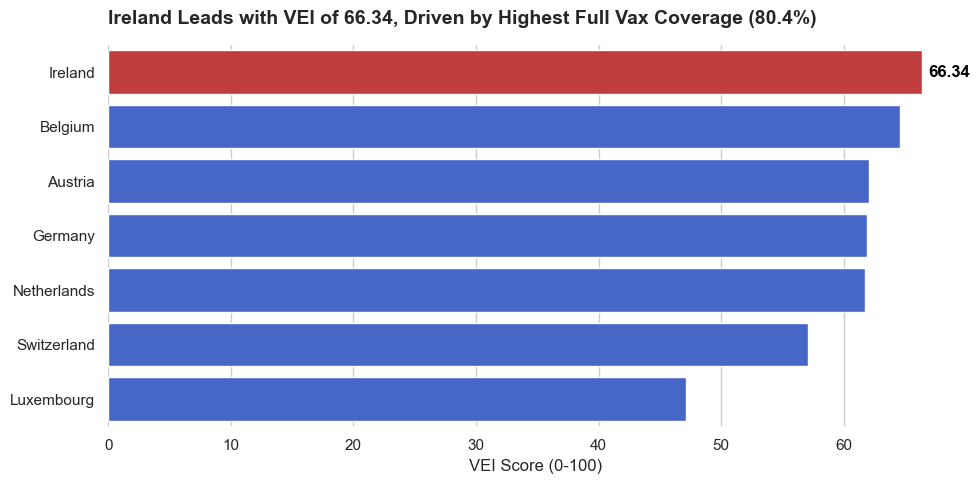

In [1523]:
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_vei_final.sort_values('VEI_Score', ascending=False)

# เน้นสีแดงที่ค่าสูงสุด สีฟ้าที่เหลือ
colors = [COLOR_RED if x == df_plot['VEI_Score'].max() else COLOR_BLUE for x in df_plot['VEI_Score']]

sns.barplot(x='VEI_Score', y=df_plot.index, data=df_plot, palette=colors, ax=ax)

# ใส่ Data Label ท้ายบาร์
ax.bar_label(ax.containers[0], fmt='%.2f', padding=5, color='black', fontweight='bold')

# Action Title ดึงค่าจากกราฟ
max_score = df_plot['VEI_Score'].max()
max_cov = df_plot.loc[df_plot['VEI_Score'].idxmax(), 'Coverage_Score']
ax.set_title(f"Ireland Leads with VEI of {max_score:.2f}, Driven by Highest Full Vax Coverage ({max_cov:.1f}%)", 
             fontsize=14, fontweight='bold', pad=15, loc='left')

ax.set_xlabel("VEI Score (0-100)", fontsize=12)
ax.set_ylabel("")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Chart 2: Line Chart shows when did campaigns start, how fast did they scale, and where do they stand at the end of the dataset?

Justification: Use pre-attentive attributes (color hue) to distinguish countries. Use a line chart, which is best suited for time series, and choose a color palette that is clearly visible (colorblind-friendly).

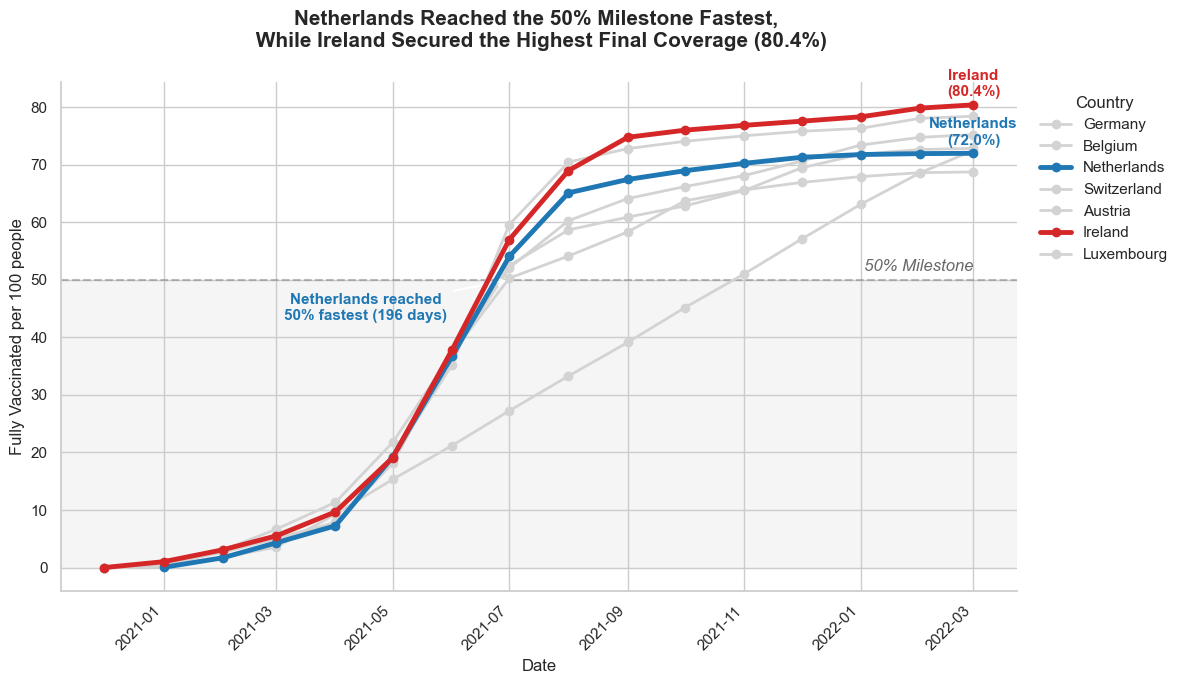

In [1524]:
# 1. กำหนดรายชื่อประเทศและเตรียมข้อมูลรายเดือนจาก df_vacc_we
target_countries = ['Germany', 'Belgium', 'Netherlands', 'Switzerland', 'Austria', 'Ireland', 'Luxembourg']

df_monthly_vax = df_vacc_we[df_vacc_we['country'].isin(target_countries)].copy()
df_monthly_vax = df_monthly_vax.groupby(['country', df_monthly_vax['date'].dt.to_period('M')])['people_fully_vaccinated_per_hundred'].max().reset_index()
df_monthly_vax['date'] = df_monthly_vax['date'].dt.to_timestamp()

# 2. สร้างกราฟ
fig, ax = plt.subplots(figsize=(12, 7))

# 3. ลูปพล็อตทีละประเทศ พร้อมตั้งค่าสีและความหนาเพื่อเน้น Insight
for country in target_countries:
    country_data = df_monthly_vax[df_monthly_vax['country'] == country].sort_values('date')
    
    if country_data.empty:
        continue
        
    # กำหนดสีและความหนา: เน้น Ireland (จบสูงสุด) และ Netherlands (ถึง 50% ไวสุด)
    if country == 'Ireland':
        line_color = '#d62728' # สีแดง
        line_width = 3.5
        z_order = 5 # ให้อยู่เลเยอร์บนสุด
    elif country == 'Netherlands':
        line_color = '#1f77b4' # สีฟ้า
        line_width = 3.5
        z_order = 4
    else:
        line_color = '#d3d3d3' # สีเทาสำหรับประเทศอื่นๆ (เป็น Background)
        line_width = 2.0
        z_order = 2 
        
    # พล็อตเส้น
    line, = ax.plot(country_data['date'], country_data['people_fully_vaccinated_per_hundred'], 
                    label=country, color=line_color, linewidth=line_width, zorder=z_order,marker='o')
    
    # 4. ใส่ Label ตัวเลขที่ปลายกราฟ เฉพาะประเทศที่เด่น (Ireland & Netherlands)
    if country in ['Ireland', 'Netherlands']:
        last_row = country_data.iloc[-1]
        ax.text(last_row['date'], last_row['people_fully_vaccinated_per_hundred'] + 1.5, 
                f"{country}\n({last_row['people_fully_vaccinated_per_hundred']:.1f}%)", 
                fontsize=11, fontweight='bold', color=line_color, ha='center')

# 5. ตกแต่งเส้นอ้างอิง 50% Milestone
ax.axhline(50, ls='--', color='gray', alpha=0.5, zorder=1)
ax.axhspan(0, 50, color="#c7bfbf", alpha=0.15, zorder=0)

max_date = df_monthly_vax['date'].max()
ax.text(max_date, 51.5, '50% Milestone', color='dimgray', style='italic', ha='right')

# 6. เพิ่มลูกศรชี้ (Annotation) จุดที่ Netherlands ถึง 50% ไวที่สุด
nl_data = df_monthly_vax[df_monthly_vax['country'] == 'Netherlands']
nl_50_date = nl_data[nl_data['people_fully_vaccinated_per_hundred'] >= 50]['date'].min()
if pd.notnull(nl_50_date):
    ax.annotate('Netherlands reached\n50% fastest (196 days)', 
                xy=(nl_50_date, 50), 
                xytext=(nl_50_date - pd.Timedelta(days=75), 43), # ขยับข้อความไปด้านบนซ้าย
                arrowprops=dict(facecolor='#1f77b4', arrowstyle="->", lw=1.5, alpha=1),
                fontsize=11, color='#1f77b4', fontweight='bold', ha='center')

# 7. Action Title ที่สรุป Insight ทั้งเรื่องความเร็วและจุดจบ
action_title = "Netherlands Reached the 50% Milestone Fastest, \n While Ireland Secured the Highest Final Coverage (80.4%)"
ax.set_title(action_title, fontsize=15, fontweight='bold', pad=25, loc='center')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Fully Vaccinated per 100 people", fontsize=12)

# ปรับแกน X ให้เอียงอ่านง่าย
plt.xticks(rotation=45, ha='right')

# แสดง Legend ไว้เพื่ออ้างอิงประเทศสีเทา
ax.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

### Area 2B: Variant Spread & Impact Assessment
Chart 3: Stacked Bar Chart (Variant Spread)

Justification: A Stacked Area Chart is best suited for illustrating part-to-whole relationships over time, clearly showing how new species surpass old ones.

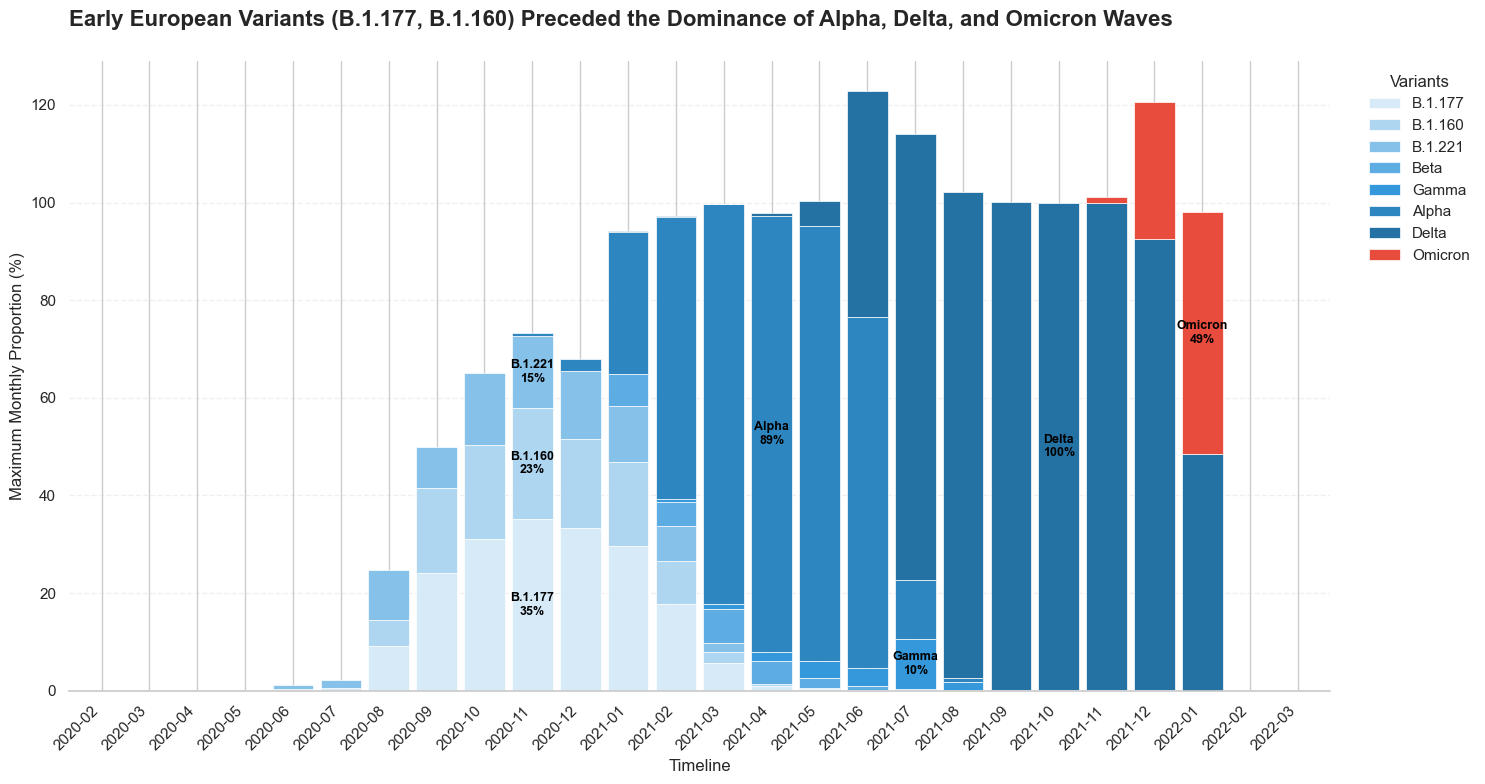

In [1525]:
# 1. นิยามกลุ่มสายพันธุ์ตามข้อมูลวิเคราะห์ (Area 2B)
# สายพันธุ์อื่นที่มีนัยสำคัญ (>5%): B.1.177, B.1.160, B.1.221, Beta, Gamma
other_vars = ['variant_B.1.177', 'variant_B.1.160', 'variant_B.1.221', 'variant_Beta', 'variant_Gamma']
main_vars = ['variant_Alpha', 'variant_Delta', 'variant_Omicron']
all_plot_vars = other_vars + main_vars

# 2. เตรียมข้อมูลรายเดือน (ดึงค่า Max ของแต่ละเดือนเพื่อให้เห็นจุด Peak ชัดเจน)
regional_daily_all = df_unified.groupby('date')[all_plot_vars].mean()
df_all_vars_monthly = regional_daily_all.groupby(regional_daily_all.index.to_period('M')).max()
df_all_vars_monthly.index = df_all_vars_monthly.index.astype(str)

# 3. สร้างกราฟ
fig, ax = plt.subplots(figsize=(15, 8))

# กำหนดสี: กลุ่มสายพันธุ์อื่นใช้สีฟ้าหลายเฉด / สายพันธุ์หลักใช้สีเน้น
colors = [
    '#D6EAF8', '#AED6F1', '#85C1E9', '#5DADE2', '#3498DB', # เฉดสีฟ้าสำหรับ Others
    '#2E86C1', # Alpha (ฟ้าเข้ม)
    '#2471A3', # Delta (น้ำเงิน)
    '#E74C3C'  # Omicron (แดงเน้น)
]

df_all_vars_monthly.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.85, edgecolor='white', linewidth=0.5)

# 4. ใส่ Label เฉพาะจุด Peak ที่สำคัญ
for i, col in enumerate(all_plot_vars):
    peak_val = df_all_vars_monthly[col].max()
    peak_idx = df_all_vars_monthly[col].idxmax()
    
    # วนลูปหาตำแหน่งแท่งกราฟเพื่อวางเลข
    for j, bar in enumerate(ax.containers[i]):
        if df_all_vars_monthly.index[j] == peak_idx and peak_val > 10:
            # คำนวณตำแหน่ง Y กึ่งกลางของส่วนนั้นๆ ใน Stack
            y_pos = bar.get_y() + bar.get_height() / 2
            ax.text(bar.get_x() + bar.get_width()/2, y_pos, 
                    f"{col.replace('variant_', '')}\n{peak_val:.0f}%", 
                    va='center', ha='center', color='black', fontsize=9, fontweight='bold')

# 5. ตกแต่ง
ax.set_title("Early European Variants (B.1.177, B.1.160) Preceded the Dominance of Alpha, Delta, and Omicron Waves", 
             fontsize=16, fontweight='bold', pad=25, loc='left')
ax.set_ylabel("Maximum Monthly Proportion (%)", fontsize=12)
ax.set_xlabel("Timeline", fontsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# ปรับ Legend
clean_labels = [c.replace('variant_', '') for c in all_plot_vars]
ax.legend(clean_labels, title="Variants", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

sns.despine(left=True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Chart 4: Multi-line Chart (COVID-19 Variant Displacement)

Emphasize visual hierarchy using color and line thickness to distinguish major species from minor species. This helps to clearly and quickly visualize "displacement" and the time it takes for a new species to become the dominant one (dominance).

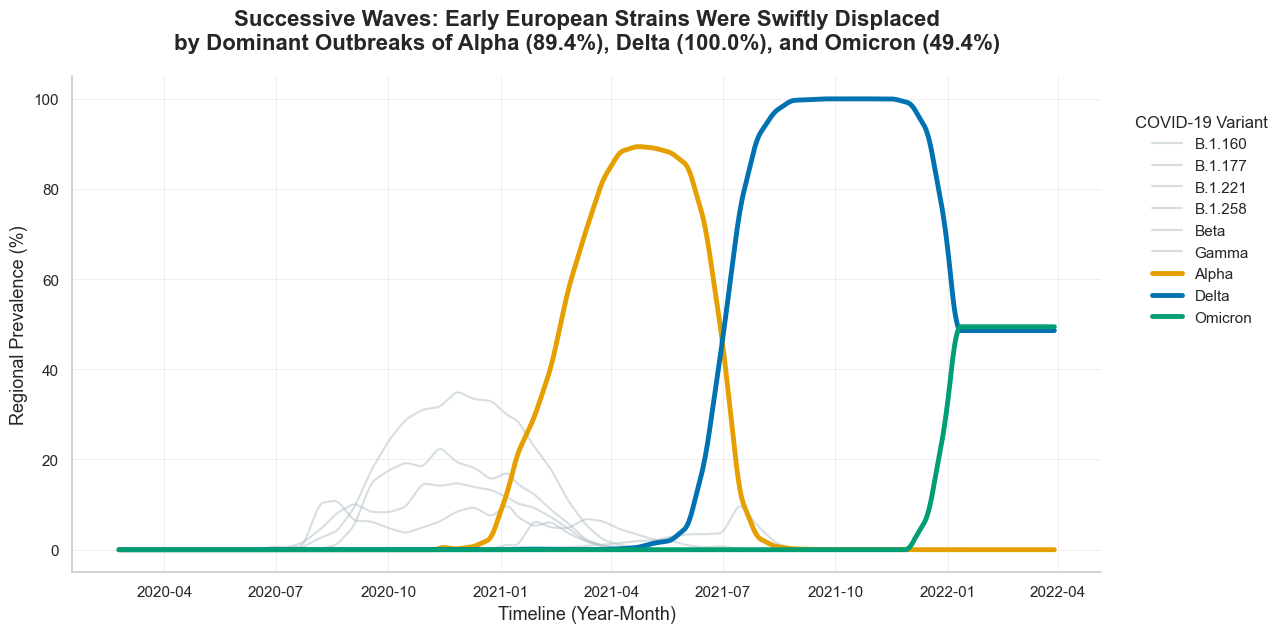

In [1526]:
# 1. เตรียมข้อมูลสายพันธุ์ทั้งหมดที่ระบาดเกิน 5% (ตามที่คุณสกัดไว้ในผลลัพธ์)
all_vars = [
    'variant_B.1.160', 'variant_B.1.177', 'variant_B.1.221', 'variant_B.1.258', 
    'variant_Beta', 'variant_Gamma', 
    'variant_Alpha', 'variant_Delta', 'variant_Omicron'
]

# ดึงข้อมูลรายวัน
df_trend = df_unified.groupby('date')[all_vars].mean()

# 💡 แปลง 0 เป็น NaN ชั่วคราว -> interpolate เชื่อมเส้น -> เติม 0 กลับ
df_trend = df_trend.replace(0, np.nan).interpolate(method='linear').fillna(0)

# ทำ Smoothing (7-day rolling) ให้เส้นสมูท
df_trend = df_trend.rolling(window=7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 6.5))

# 2. ตั้งค่าสีและการเน้นเส้น
main_vars = ['Alpha', 'Delta', 'Omicron']
# สี Colorblind-friendly สำหรับ 3 Wave หลัก
main_colors = {'Alpha': '#E69F00', 'Delta': '#0072B2', 'Omicron': '#009E73'} 

# พล็อตเส้นทีละสายพันธุ์
for var in all_vars:
    name = var.replace('variant_', '')
    
    if name in main_vars:
        # ถ้าเป็น 3 สายพันธุ์หลัก: ใช้สีสด, เส้นหนา, และดันให้อยู่เลเยอร์บนสุด (zorder=5)
        color = main_colors[name]
        lw = 3.5
        alpha_val = 1.0
        z_order = 5
    else:
        # ถ้าเป็นสายพันธุ์ดั้งเดิม/สายพันธุ์รอง: ใช้สีเทา, เส้นบาง, และให้อยู่เลเยอร์หลังสุด (zorder=2)
        color = '#B0BEC5' 
        lw = 1.5
        alpha_val = 0.5
        z_order = 2
        
    ax.plot(df_trend.index, df_trend[var], label=name, color=color, 
            linewidth=lw, alpha=alpha_val, zorder=z_order)

# --- ก่อนถึงโค้ดข้อ 3 ให้คำนวณหาค่า Peak (เปอร์เซ็นต์สูงสุด) ก่อน ---
max_alpha = df_trend['variant_Alpha'].max()
max_delta = df_trend['variant_Delta'].max()
max_omi = df_trend['variant_Omicron'].max()

# 3. ตกแต่ง Title ให้สอดคล้องกับ Insight พร้อมใส่เปอร์เซ็นต์
action_title = f"Successive Waves: Early European Strains Were Swiftly Displaced\nby Dominant Outbreaks of Alpha ({max_alpha:.1f}%), Delta ({max_delta:.1f}%), and Omicron ({max_omi:.1f}%)"
ax.set_title(action_title, fontsize=16, fontweight='bold', pad=20, loc='center')

ax.set_ylabel("Regional Prevalence (%)", fontsize=13)
ax.set_xlabel("Timeline (Year-Month)", fontsize=13)

# --- ตั้งค่าสีเส้นกริดให้อ่อนลง (Grid Customization) ---
ax.grid(True, which='both', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.5)

# จัดการ Legend ให้อยู่ด้านขวาแบบไม่มีกรอบ 
ax.legend(title="COVID-19 Variant", title_fontsize=12, fontsize=11, 
          bbox_to_anchor=(1.02, 0.95), loc='upper left', frameon=False)

# ลบขอบกราฟด้านบนและขวา
sns.despine()

plt.tight_layout()
plt.show()

Chart 5: Dual-Axis Line Chart (Vaccine vs Positivity)

Justification (Dual Axes Justification & Ethical Visualization): The use of dual axes is often perceived as misleading, but in this case, it is justified because the two variables (vaccination accumulation vs. rate of infection) have different natural scales. Overlaying them with colors to clearly separate the axes (blue for the left, red for the right) aligns with ethical visualization principles, preventing confusion and highlighting that vaccines do not stop infection (positivity spikes) but may reduce severity as analyzed.

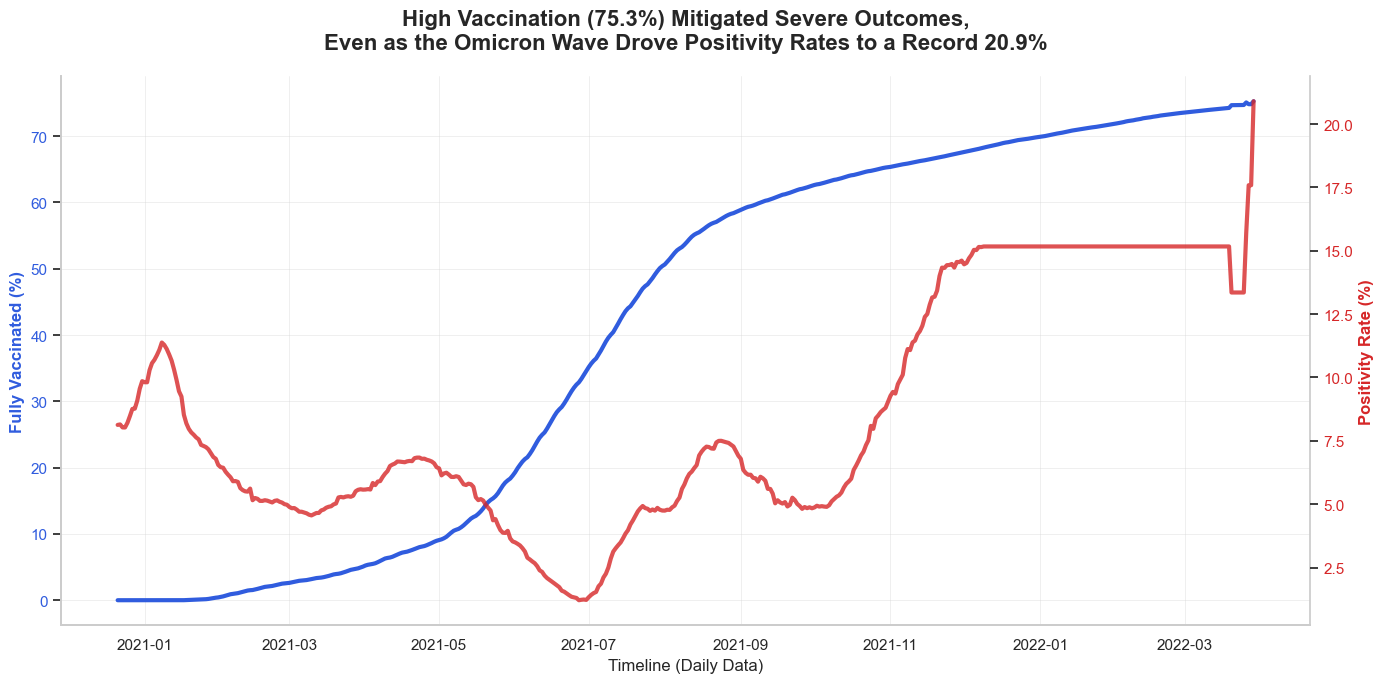

In [1527]:

# 1. คำนวณค่าเฉลี่ยวัคซีนจาก df_vacc_we (ตัวแปรต้นทางที่มีคอลัมน์นี้แน่นอน)
vax_daily = df_vacc_we.groupby('date')['people_fully_vaccinated_per_hundred'].mean().reset_index()

# 2. คำนวณค่าเฉลี่ย Positive rate จาก df_unified (หรือ df_merged ของคุณ)
pos_daily = df_unified.groupby('date')['Short-term positive rate'].mean().reset_index()

# 3. นำมารวมกันด้วย date
df_daily_region = pd.merge(vax_daily, pos_daily, on='date', how='inner')
# แปลง Positive Rate เป็นเปอร์เซ็นต์
df_daily_region['positivity_rate_pct'] = df_daily_region['Short-term positive rate'] * 100

fig, ax1 = plt.subplots(figsize=(14, 7))

# --- ตั้งค่าสีเส้นกริดให้อ่อนลง (Grid Customization) ---
ax1.grid(True, which='both', linestyle='-', linewidth=0.5, color='lightgray', alpha=0.5)

# 2. แกนซ้าย: Vaccination (สีฟ้า) - พล็อตแบบเส้นต่อเนื่องรายวัน
ax1.plot(df_daily_region['date'], df_daily_region['people_fully_vaccinated_per_hundred'], 
         color=COLOR_BLUE, linewidth=3, label='Daily Vaccination Avg')
ax1.set_ylabel('Fully Vaccinated (%)', color=COLOR_BLUE, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=COLOR_BLUE)

# 3. แกนขวา: Positivity Rate (สีแดง) - พล็อตแบบเส้นต่อเนื่องรายวัน
ax2 = ax1.twinx()
ax2.plot(df_daily_region['date'], df_daily_region['positivity_rate_pct'], 
         color=COLOR_RED, linewidth=3, alpha=0.8, label='Daily Positivity Rate')
ax2.set_ylabel('Positivity Rate (%)', color=COLOR_RED, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=COLOR_RED)

# ปรับปรุงเส้นกริดของแกนที่สองให้ตรงกันหรือซ่อนไว้เพื่อไม่ให้ลายตา (เลือกใช้กริดจาก ax1 เป็นหลัก)
ax2.grid(False) 

# 4. ดึงค่าสูงสุดมาใส่ใน Action Title
max_pos = df_daily_region['positivity_rate_pct'].max()
max_vax = df_daily_region['people_fully_vaccinated_per_hundred'].max()

# Action Title: ชี้ให้เห็นว่าวัคซีนไม่ได้หยุดการติดเชื้อ (Transmission) แต่ไปลดความรุนแรง (Severity) แทน
title_text = f"High Vaccination ({max_vax:.1f}%) Mitigated Severe Outcomes,\n" \
             f"Even as the Omicron Wave Drove Positivity Rates to a Record {max_pos:.1f}%"

plt.title(title_text, fontsize=16, fontweight='bold', pad=20, loc='center')

# 5. จัดการแกน X (วันที่)
ax1.set_xlabel("Timeline (Daily Data)", fontsize=12)
plt.xticks(rotation=45)

# ลบขอบด้านบนออก (คงขอบซ้าย-ขวา-ล่างไว้สำหรับ Dual Axis)
sns.despine(ax=ax1, top=True, right=False)

plt.tight_layout()
plt.show()

### Area 2C: Vaccine Manufacturer Comparison
Chart 6: Faceted Chart (Vaccine Usage)

Justification: Using faceted charts (small multiples) reduces cognitive load. Readers can instantly compare proportions between countries without having to strain their eyes looking at the colors in complex stacked bar charts. This is the ultimate respect for the data-ink ratio principle.

c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

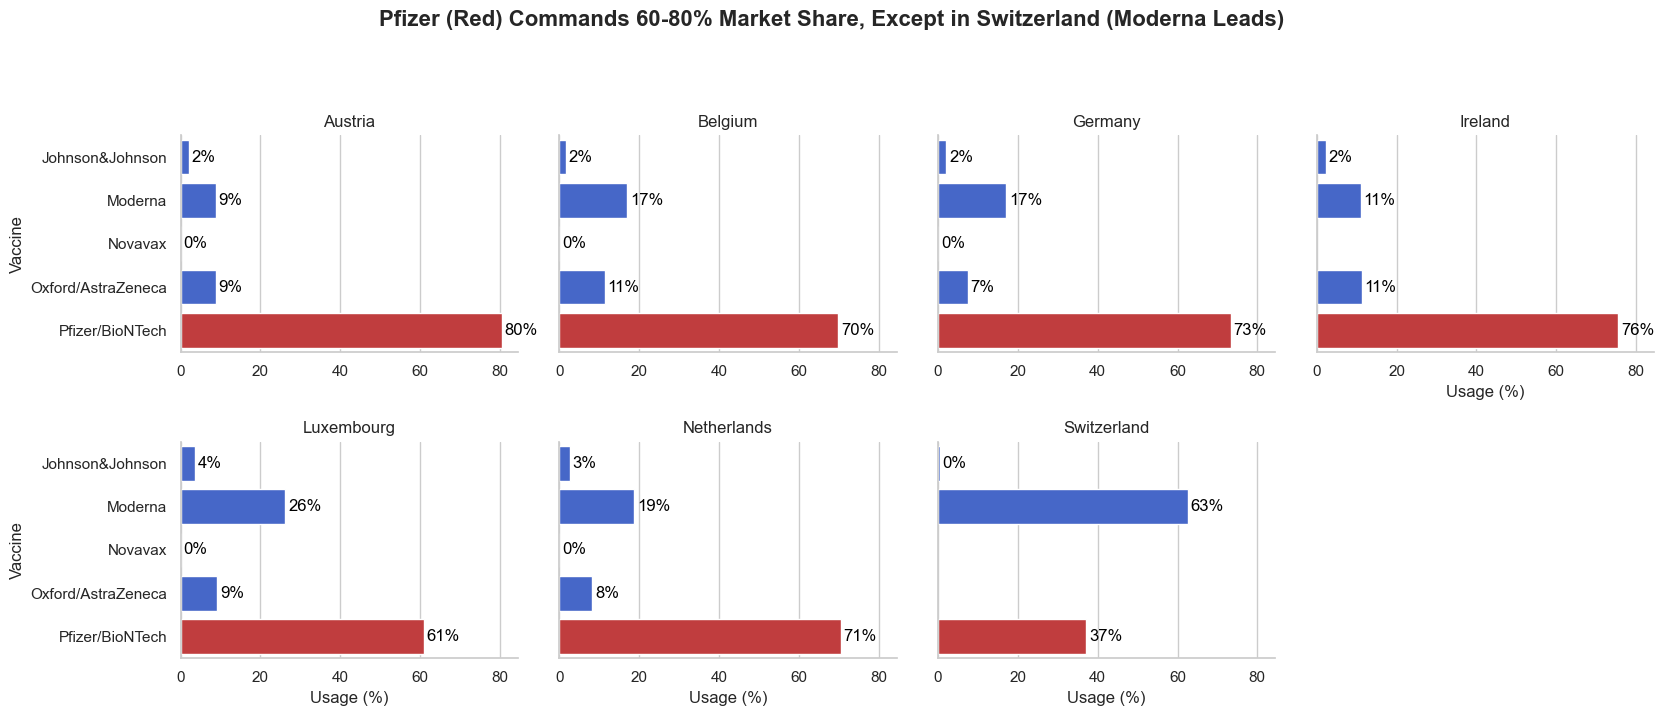

In [1528]:
df_mfr_melt = df_mfr_pct.reset_index().melt(id_vars='country', var_name='Vaccine', value_name='Percentage')
df_mfr_melt['Vaccine'] = df_mfr_melt['Vaccine'].str.replace('vaccine_', '')

# สี: แดงให้ Pfizer นอกนั้นฟ้า
pal = {v: COLOR_RED if 'Pfizer' in v else COLOR_BLUE for v in df_mfr_melt['Vaccine'].unique()}

g = sns.FacetGrid(df_mfr_melt, col="country", col_wrap=4, height=3.5, aspect=1.2)
g.map_dataframe(sns.barplot, x="Percentage", y="Vaccine", palette=pal)

# ใส่ Label ท้าย Bar ในแต่ละ Subplot
for ax in g.axes.flat:
    for c in ax.containers:
        ax.bar_label(c, fmt='%.0f%%', padding=2, color='black')
    
    # [แก้ข้อ 2] บังคับให้แสดงตัวเลขแกน X และชื่อแกนในทุกกราฟย่อย (ปกติ FacetGrid จะซ่อนแถวบนไว้)
    ax.tick_params(labelbottom=True)
    ax.set_xlabel("Usage (%)")

# ไม่ต้องใช้ g.set_axis_labels แล้ว เพราะเรา set ไปใน for loop ด้านบนแล้ว
g.fig.suptitle("Pfizer (Red) Commands 60-80% Market Share, Except in Switzerland (Moderna Leads)", 
               fontsize=16, fontweight='bold', y=1.02) # ปรับ y ลงมาเล็กน้อยให้พอดีกับพื้นที่ใหม่

g.set_titles(col_template="{col_name}")
sns.despine()

# [แก้ข้อ 1] ใช้ h_pad เพื่อเพิ่มช่องว่างระหว่างแถวบน-ล่าง และใช้ rect เพื่อเว้นที่ด้านบนสุดให้ Title
plt.tight_layout(h_pad=2.5, rect=[0, 0, 1, 0.95])
plt.show()

Chart 7: Bar Chart (MRRS Score)

Justification: We present our proprietary Mass Result Reduction Rate (MRRS) score using a bar graph to highlight the enormous difference between mRNA vaccines (Pfizer, Moderna) and viral vector vaccines (AstraZeneca, Johnson & Johnson).

C:\Users\Admin\AppData\Local\Temp\ipykernel_1860\1682054446.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_MRRS_Score', y='Manufacturer', data=df_mrrs_plot, palette=colors, ax=ax)


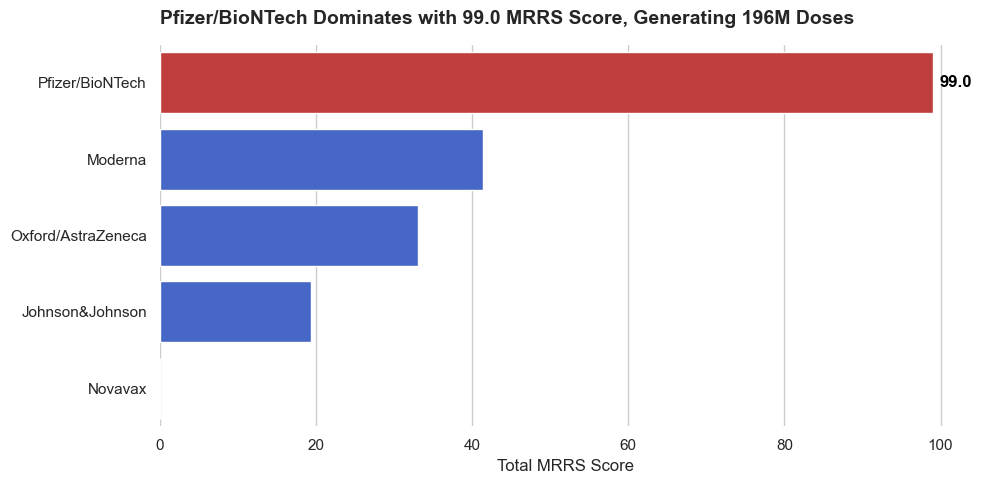

In [1529]:
fig, ax = plt.subplots(figsize=(10, 5))
df_mrrs_plot = df_mrrs_final.reset_index().sort_values('Total_MRRS_Score', ascending=False)

colors = [COLOR_RED if val == df_mrrs_plot['Total_MRRS_Score'].max() else COLOR_BLUE for val in df_mrrs_plot['Total_MRRS_Score']]

sns.barplot(x='Total_MRRS_Score', y='Manufacturer', data=df_mrrs_plot, palette=colors, ax=ax)

# ใส่ Label ท้าย Bar
ax.bar_label(ax.containers[0], fmt='%.1f', padding=5, color='black', fontweight='bold')

max_score = df_mrrs_plot['Total_MRRS_Score'].max()
top_vax = df_mrrs_plot.iloc[0]['Manufacturer']
total_doses_m = df_mrrs_plot.iloc[0]['Total_Doses'] / 1000000

ax.set_title(f"{top_vax} Dominates with {max_score:.1f} MRRS Score, Generating {total_doses_m:.0f}M Doses", 
             fontsize=14, fontweight='bold', pad=15, loc='left')
ax.set_xlabel("Total MRRS Score", fontsize=12)
ax.set_ylabel("")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Area 2D: Testing Capacity & Pandemic Response
Chart 8: Scatter Plot (Tests vs Cases)

Justification: The use of scatter plots in conjunction with regression lines and confidence intervals (red areas) clearly confirms the positive relationship between the number of tests conducted and the number of reported infections. Adjusting the data to a "per 1,000 people" scale eliminates population size disparities, allowing for fair comparisons of testing efficiency across countries. Direct labeling at key points reduces the cognitive load in data interpretation.

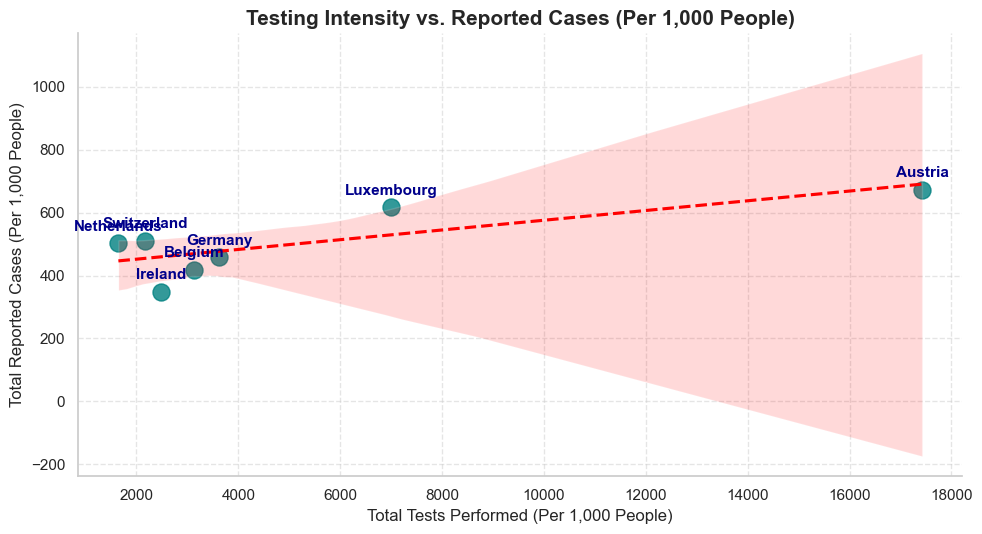

In [1530]:
# 1. รีเซ็ต Index เพื่อให้ดึงชื่อประเทศมาแปะในกราฟได้ง่ายขึ้น
df_plot = df_test_cases.reset_index().rename(columns={'index': 'country'})

# 2. ตั้งค่าขนาดกราฟและสไตล์
plt.figure(figsize=(10, 5.5))

# 3. พล็อตกราฟ Scatter Plot พร้อมเส้น Regression Line
sns.regplot(
    data=df_plot, 
    x='Tests_per_1000', 
    y='Cases_per_1000', 
    scatter_kws={'s': 150, 'color': 'teal', 'alpha': 0.8}, # ปรับขนาดและสีของจุด
    line_kws={'color': 'red', 'linestyle': '--'}          # ปรับสีและรูปแบบเส้นแนวโน้ม
)

# 4. วนลูปเพื่อแปะชื่อประเทศลงบนจุดแต่ละจุด
for i, row in df_plot.iterrows():
    plt.text(
        x=row['Tests_per_1000'], 
        y=row['Cases_per_1000'] + 40,  # ขยับตัวหนังสือขึ้นไปเหนือจุดเล็กน้อย
        s=row['country'], 
        fontsize=11, 
        ha='center',
        fontweight='bold',
        color='darkblue'
    )

# 5. ตกแต่งกราฟ (ชื่อกราฟ, แกน X, แกน Y)
plt.title('Testing Intensity vs. Reported Cases (Per 1,000 People)', fontsize=15, fontweight='bold')
plt.xlabel('Total Tests Performed (Per 1,000 People)', fontsize=12)
plt.ylabel('Total Reported Cases (Per 1,000 People)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Chart 9: Line/Area Chart (Positivity Rate)

Justification: The use of red (crimson) color and filling under the graph utilizes pre-attentive attributes to quickly convey the danger/crisis point of a new wave of the outbreak.

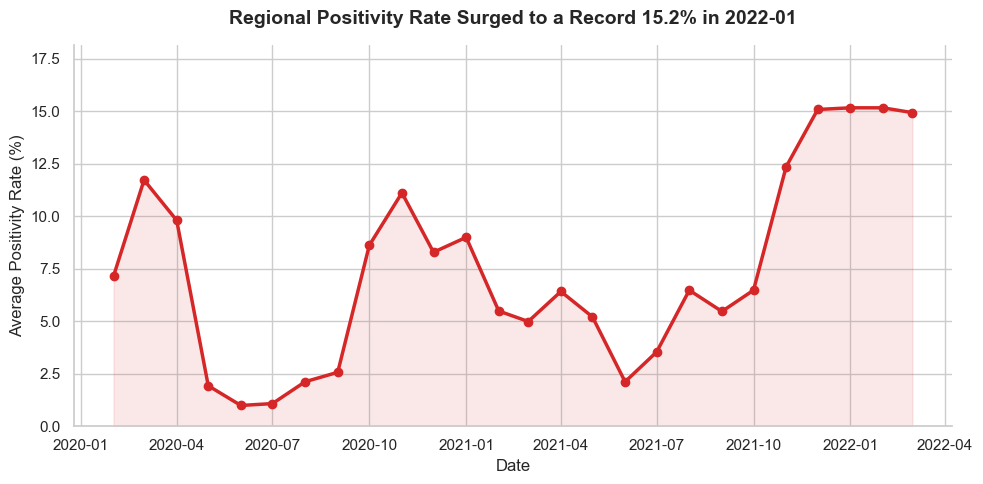

In [1531]:
fig, ax = plt.subplots(figsize=(10, 5))

regional_testing['Date'] = pd.to_datetime(regional_testing['Month-Year'])

# พล็อตเส้นและจุด
ax.plot(regional_testing['Date'], regional_testing['Positivity Rate (Avg %)'], 
        color=COLOR_RED, marker='o', linewidth=2.5)

# ถมสีใต้กราฟ (Area)
ax.fill_between(regional_testing['Date'], regional_testing['Positivity Rate (Avg %)'], 
                color=COLOR_RED, alpha=0.1)


max_pos = regional_testing['Positivity Rate (Avg %)'].max()
peak_date = regional_testing.loc[regional_testing['Positivity Rate (Avg %)'].idxmax(), 'Month-Year']

ax.set_title(f"Regional Positivity Rate Surged to a Record {max_pos:.1f}% in {peak_date}", 
             fontsize=14, fontweight='bold', pad=15, loc='center')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Average Positivity Rate (%)", fontsize=12)
ax.set_ylim(0, max_pos + 3) # เพิ่มพื้นที่ด้านบนให้ Label ไม่ล้นกรอบ

sns.despine()
plt.tight_layout()
plt.show()

Chart 10: Small Multiple Line Charts (Testing Capacity Trends)

Justification: Using Small Multiples in conjunction with Independent Y-Axes provides a clear view of the "response rhythm" and "waves of the epidemic" in each country, without the extremely high values ​​of large countries like Germany obscuring the data of smaller countries and resulting in a flat, straight line.

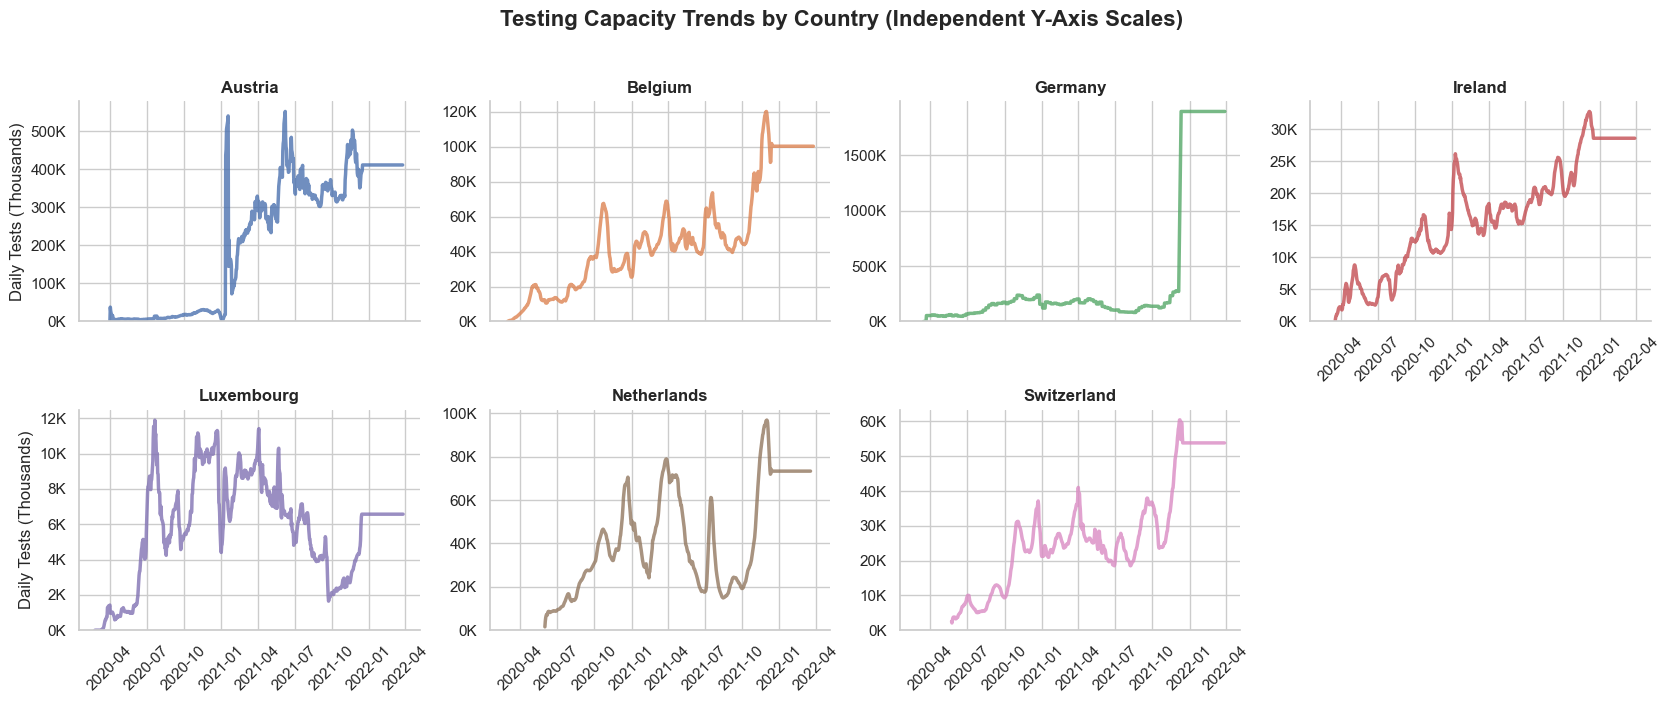

In [1532]:
# 1. เตรียมข้อมูล (ใช้ตัวเดิมที่มี 7-day smoothed)
df_plot = df_unified[['country', 'date', 'Daily change in cumulative total']].copy()
df_plot['smoothed_tests'] = df_plot.groupby('country')['Daily change in cumulative total'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df_plot['smoothed_tests_k'] = df_plot['smoothed_tests'] / 1000

# 2. สร้าง FacetGrid โดยตั้งค่า sharey=False (หัวใจสำคัญอยู่ตรงนี้ครับ)
sns.set_theme(style="whitegrid")
g = sns.FacetGrid(df_plot, col="country", hue="country", col_wrap=4, 
                  height=3.5, aspect=1.2, 
                  sharey=False) # <--- เปลี่ยนตรงนี้เพื่อให้สเกลแต่ละรูปแยกกัน

# 3. พล็อตเส้นกราฟ
g.map(sns.lineplot, "date", "smoothed_tests_k", linewidth=2.5, alpha=0.8)

# 4. ปรับแต่ง Formatting
g.set_titles(col_template="{col_name}", size=12, fontweight='bold')
g.set_axis_labels("", "Daily Tests (Thousands)")

for ax in g.axes.flat:
    # ปรับสเกลแกน Y ให้เติม K และจัดการตัวเลขให้เหมาะสมกับสเกลที่แยกกัน
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x)}K" if x != 0 else "0K"))
    ax.tick_params(axis='x', labelrotation=45)
    
    # เพิ่มเติม: ปรับให้แกน Y เริ่มต้นที่ 0 เสมอเพื่อไม่ให้กราฟดูหลอกตา
    ax.set_ylim(bottom=0)

plt.subplots_adjust(top=0.85, hspace=0.4) # เพิ่ม hspace เพื่อไม่ให้กราฟซ้อนกันเมื่อสเกลต่างกัน
g.fig.suptitle('Testing Capacity Trends by Country (Independent Y-Axis Scales)', 
               fontsize=16, fontweight='bold')

plt.show()